/Users/artempopov/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


(1671447, 10)
['x_mm', 'y_mm', 'z_mm', 'energy_deposition_mev', 'particle', 'particle_role', 'layer_name', 'material_name', 'event_id', 'track_id']


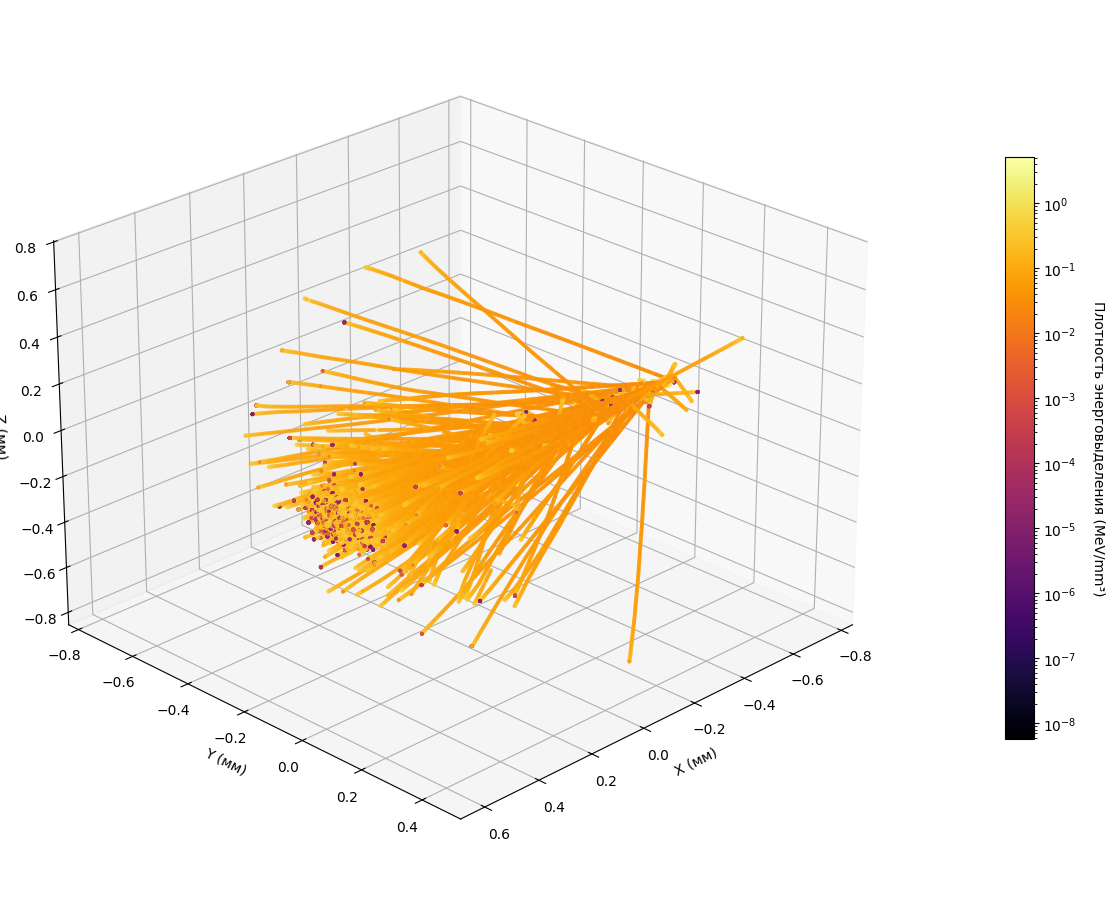

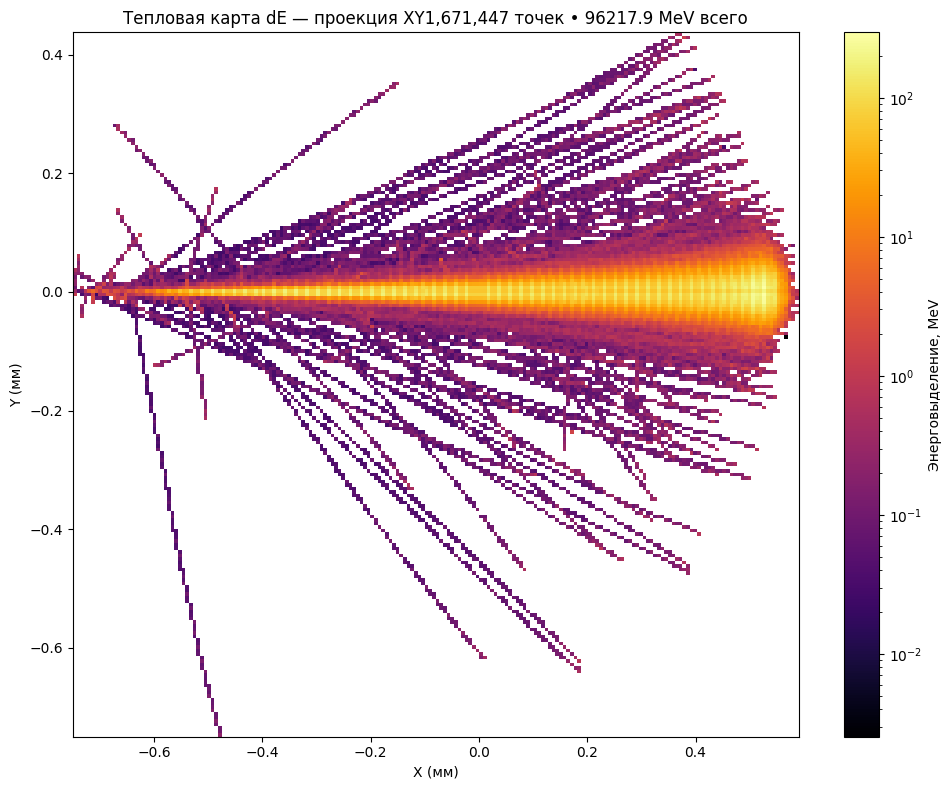

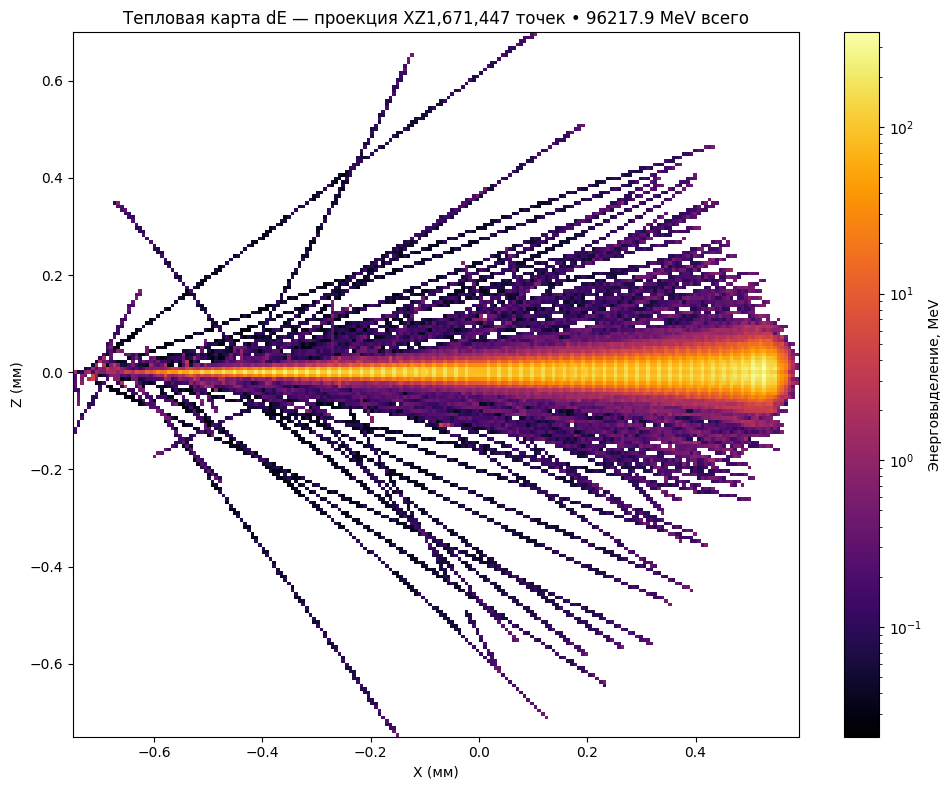

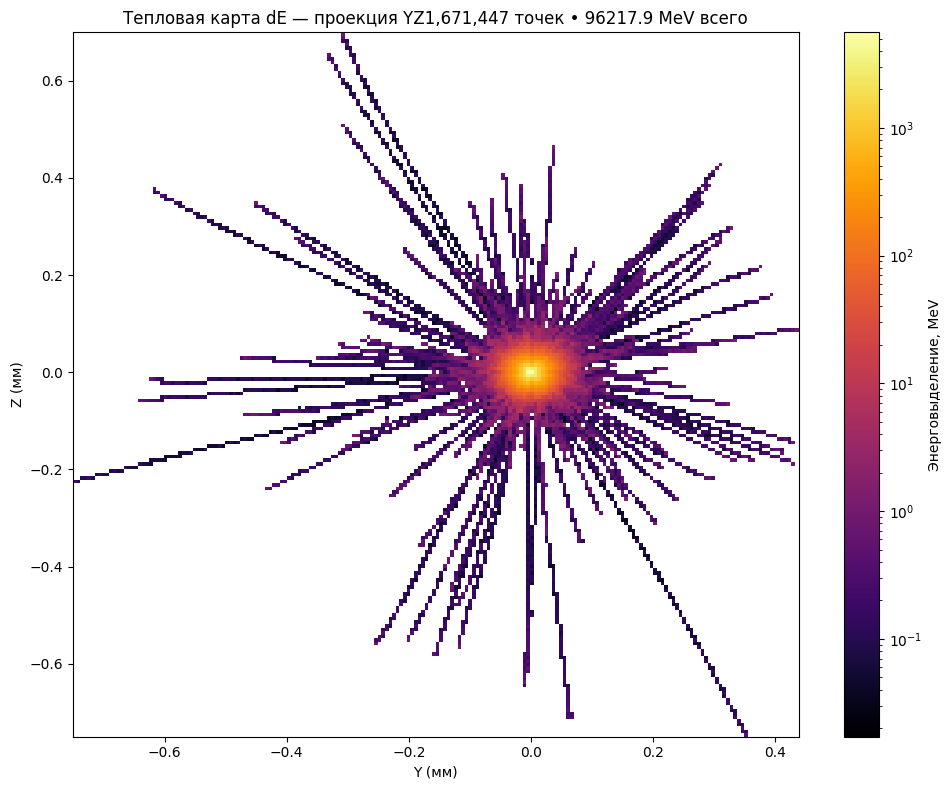

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# ====================== ЗАГРУЗКА ======================
df = pd.read_csv("test.csv")

print(df.shape)
print(df.columns.tolist())

x, y, z = df["x_mm"], df["y_mm"], df["z_mm"]
xlabel, ylabel, zlabel = "X (мм)", "Y (мм)", "Z (мм)"
density = df["energy_deposition_mev"]

# Нормализация для цвета и размера
norm = mcolors.LogNorm(vmin=density.min(), vmax=density.max())
colors = plt.cm.inferno(norm(density))
sizes = 8 + 40 * (density / density.max())   # размер точки зависит от плотности

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    x, y, z,
    c=colors,
    s=sizes,
    alpha=0.75,      # прозрачность
    edgecolors='none'
)

ax.set_xlabel('X (мм)')
ax.set_ylabel('Y (мм)')
ax.set_zlabel('Z (мм)')

# Цветовая шкала
sm = plt.cm.ScalarMappable(cmap='inferno', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('Плотность энерговыделения (MeV/mm³)', rotation=270, labelpad=20)

# Красивый вид
ax.view_init(elev=25, azim=45)   # поменяйте углы обзора
plt.tight_layout()
plt.show()

# ====================== ПРОЕКЦИИ ======================

# Выберите проекции (самые популярные):
projects = ["xy", "xz", "yz"]          # или "xz", "yz"

for proj in projects:

    if proj == "xy":
        x, y = df["x_mm"], df["y_mm"]
        xlabel, ylabel = "X (мм)", "Y (мм)"
    elif proj == "xz":
        x, y = df["x_mm"], df["z_mm"]
        xlabel, ylabel = "X (мм)", "Z (мм)"
    else:  # yz
        x, y = df["y_mm"], df["z_mm"]
        xlabel, ylabel = "Y (мм)", "Z (мм)"

    weights = df["energy_deposition_mev"]

    plt.figure(figsize=(10, 8))
    plt.hist2d(
        x, y,
        bins=200,                    # поменяйте на 100 / 300 / 500 по вкусу
        weights=weights,
        cmap="inferno",              # или "viridis", "plasma", "jet"
        norm=plt.cm.colors.LogNorm() # логарифмическая шкала (очень рекомендуется)
    )

    plt.colorbar(label="Энерговыделение, MeV")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(
        f"Тепловая карта dE — проекция {proj.upper()}"
        f"{len(df):,} точек • {weights.sum():.1f} MeV всего"
    )
    plt.grid(False)
    plt.tight_layout()
    plt.show()


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("Effective traks/20_secondary.csv")
df['particle'].unique()

array(['proton', 'neutron', 'be9', 'alpha', 'deuteron', 'gamma', 'he3',
       'li6', 'li7', 'triton', 'be8', 'electron'], dtype=object)

In [24]:
df

,x_mm,y_mm,z_mm,kinetic_energy_mev,energy_deposition_mev,step_length_mm,track_length_mm,particle,particle_role,event_id,track_id,step_number,generation,parent_id,process,layer_name,material_name
0,-0.7754,0.004495,0.006029,7.5830,0.0000,0.000000,0.00000,proton,secondary,2,2,0,1,1,initStep,G4_Be,G4_Be
1,0.5990,0.010640,-0.024480,2.3520,0.0000,0.000000,0.00000,neutron,secondary,5,2,0,1,1,initStep,G4_Be,G4_Be
2,-0.4363,-0.001476,-0.006542,5.3020,0.0000,0.000000,0.00000,proton,secondary,8,2,0,1,1,initStep,G4_Be,G4_Be
3,-0.4696,-0.005699,0.013090,4.0170,0.0000,0.000000,0.00000,proton,secondary,8,2,0,1,1,initStep,G4_Be,G4_Be
4,-0.7646,0.002329,-0.002044,0.5079,0.0000,0.000000,0.00000,be9,secondary,11,2,0,1,1,initStep,G4_Be,G4_Be
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25270,-0.6541,0.572700,0.825300,0.0000,0.1407,974.000000,974.00000,alpha,secondary,380,11,1,2,2,ionIoni,G4_Be,G4_Be
25271,0.6942,0.957900,-0.024310,3.1110,0.0000,0.000000,0.00000,alpha,secondary,101,12,0,2,2,initStep,G4_Be,G4_Be
25272,0.6988,0.958100,-0.026250,2.0650,1.0470,0.005000,0.00500,alpha,secondary,101,12,1,2,2,UserMaxStep,G4_Be,G4_Be
25273,0.7034,0.958300,-0.028220,0.8533,1.2110,0.005000,0.01000,alpha,secondary,101,12,2,2,2,UserMaxStep,G4_Be,G4_Be


In [23]:
df['track_id'].unique()

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

Первичные: 1,295,275 точек, ΣdE = 55876.533 MeV
Вторичные: 2,764 точек, ΣdE = 722.756 MeV


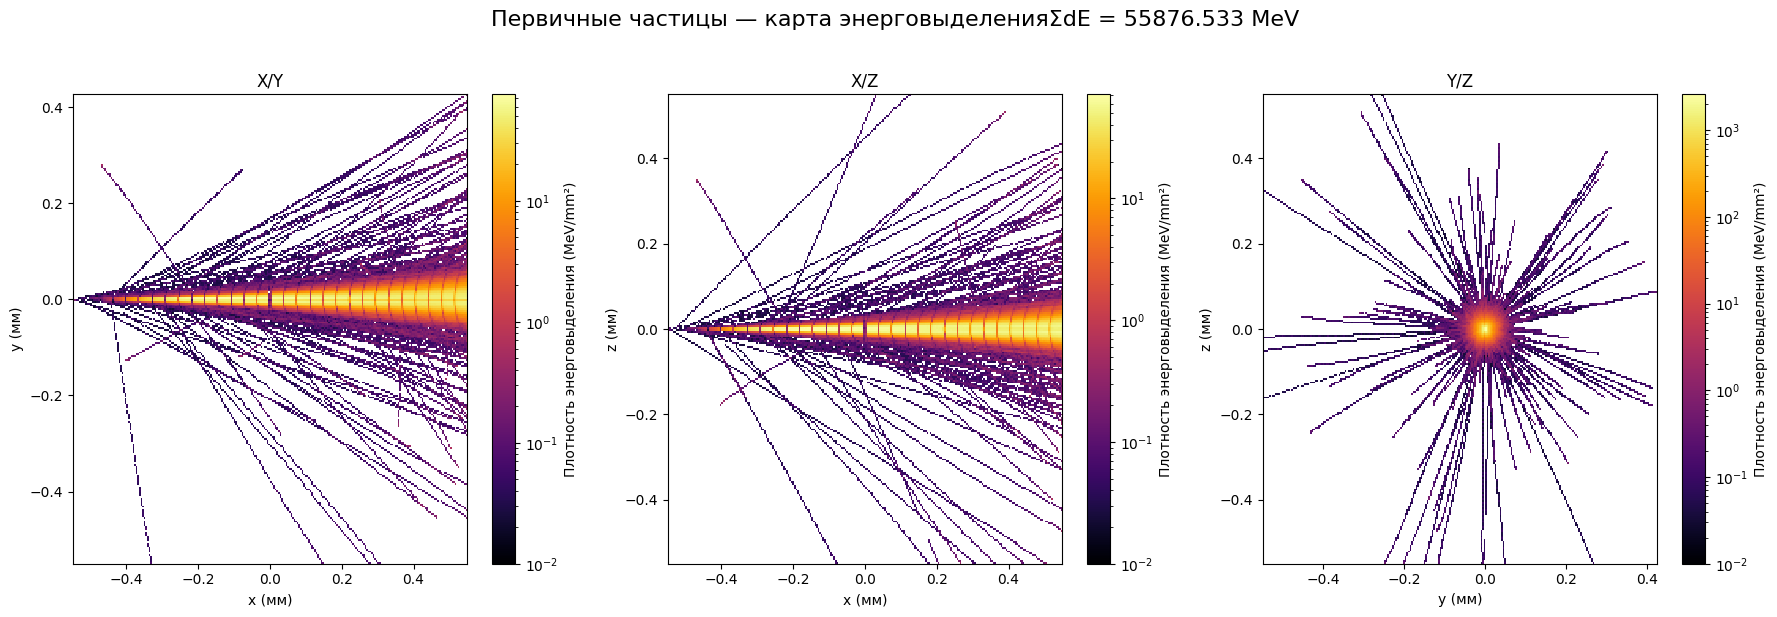

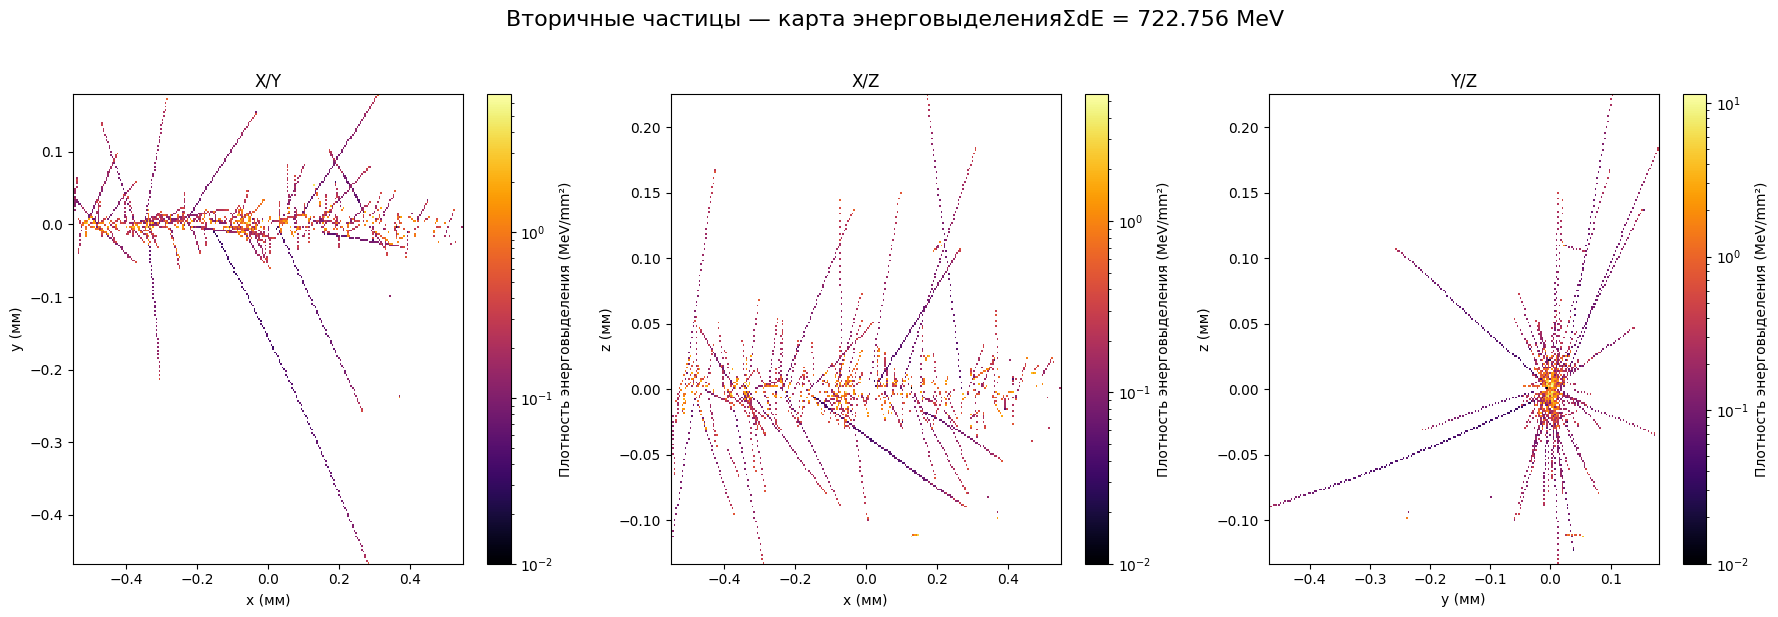

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Загрузка
df_primary = pd.read_csv("Effective traks/primary_de_points_13_MeV.csv")
df_secondary = pd.read_csv("Effective traks/secondary_de_points_13_MeV.csv")

print(f"Первичные: {len(df_primary):,} точек, ΣdE = {df_primary['energy_deposition_mev'].sum():.3f} MeV")
print(f"Вторичные: {len(df_secondary):,} точек, ΣdE = {df_secondary['energy_deposition_mev'].sum():.3f} MeV")

def plot_de_heatmaps(df, title_prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        f"{title_prefix} — карта энерговыделения"
        f"ΣdE = {df['energy_deposition_mev'].sum():.3f} MeV",
        fontsize=16,
        y=1.02,
    )

    projections = [("x_mm", "y_mm", "X/Y"),
                   ("x_mm", "z_mm", "X/Z"),
                   ("y_mm", "z_mm", "Y/Z")]

    for ax, (colx, coly, proj) in zip(axes, projections):
        x = df[colx]
        y = df[coly]
        weights = df["energy_deposition_mev"]

        h = ax.hist2d(x, y, bins=250, weights=weights,
                      cmap='inferno', norm=plt.cm.colors.LogNorm(vmin=1e-2))

        ax.set_xlabel(colx.replace("_mm", " (мм)"))
        ax.set_ylabel(coly.replace("_mm", " (мм)"))
        ax.set_title(proj)
        fig.colorbar(h[3], ax=ax, label='Плотность энерговыделения (MeV/mm²)')

    plt.tight_layout()
    plt.show()

# Построение
plot_de_heatmaps(df_primary, "Первичные частицы")
plot_de_heatmaps(df_secondary, "Вторичные частицы")


In [2]:
def build_voxel_grid(df, num_particles=10000, bins=(200, 200, 200)):
    x = df["x_mm"].values
    y = df["y_mm"].values
    z = df["z_mm"].values
    weights = df["energy_deposition_mev"].values / num_particles

    H, edges = np.histogramdd(
        sample=(x, y, z),
        bins=bins,
        weights=weights
    )

    return H, edges

def pad_voxel_grid(H, target_shape):
    H_new = np.zeros(target_shape)

    # текущие размеры
    nx, ny, nz = H.shape
    NX, NY, NZ = target_shape

    # центрирование
    x_start = (NX - nx) // 2
    y_start = (NY - ny) // 2
    z_start = (NZ - nz) // 2

    H_new[
        x_start:x_start+nx,
        y_start:y_start+ny,
        z_start:z_start+nz
    ] = H

    return H_new

def pad_edges(edges, old_shape, new_shape):
    new_edges = []

    for i in range(3):
        old_edges = edges[i]
        dx = old_edges[1] - old_edges[0]

        old_n = old_shape[i]
        new_n = new_shape[i]

        extra = (new_n - old_n) // 2

        start = old_edges[0] - extra * dx
        end = old_edges[-1] + extra * dx

        new_edges.append(np.linspace(start, end, new_n + 1))

    return new_edges

H, edges = build_voxel_grid(df_primary)

print("ΣdE (grid):", H.sum())
print("ΣdE (original):", df_primary["energy_deposition_mev"].sum())

ΣdE (grid): 12.090179764009381
ΣdE (original): 120901.79764009376


In [3]:
# Вычисляем размеры вокселей
x_edges, y_edges, z_edges = edges
dx = np.diff(x_edges)  # массив длин по x (должен быть постоянным, если равномерная сетка)
dy = np.diff(y_edges)
dz = np.diff(z_edges)

# Объём одного вокселя (мм³). Если сетка равномерная — можно взять dx[0]*dy[0]*dz[0]
# Но лучше сделать полный meshgrid для надёжности
dx_grid, dy_grid, dz_grid = np.meshgrid(dx, dy, dz, indexing='ij')
voxel_volume = dx_grid * dy_grid * dz_grid   # мм³

# Теперь правильная объёмная плотность на 1 протон
epsilon = H / voxel_volume          # MeV / мм³  на один протон

total_E_from_grid = np.sum(H)                    # должно ≈ df.sum() / 10000
total_E_from_density = np.sum(epsilon * voxel_volume)
print(total_E_from_grid, total_E_from_density)

12.090179764009381 12.090179764009381


In [5]:
def convert_to_density(H, edges):
    dx = edges[0][1] - edges[0][0]
    dy = edges[1][1] - edges[1][0]
    dz = edges[2][1] - edges[2][0]

    voxel_volume = dx * dy * dz  # мм^3

    return H / voxel_volume

H_density = convert_to_density(H, edges)

total_energy_1 = H.sum()

dx = edges[0][1] - edges[0][0]
dy = edges[1][1] - edges[1][0]
dz = edges[2][1] - edges[2][0]

total_energy_2 = (H_density * dx * dy * dz).sum()

print(total_energy_1, total_energy_2)

15.647175060416096 15.647175060416096


/var/folders/yt/7vbmq7mx6q9_q2s3p_mf_srr0000gn/T/ipykernel_51310/2672872596.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


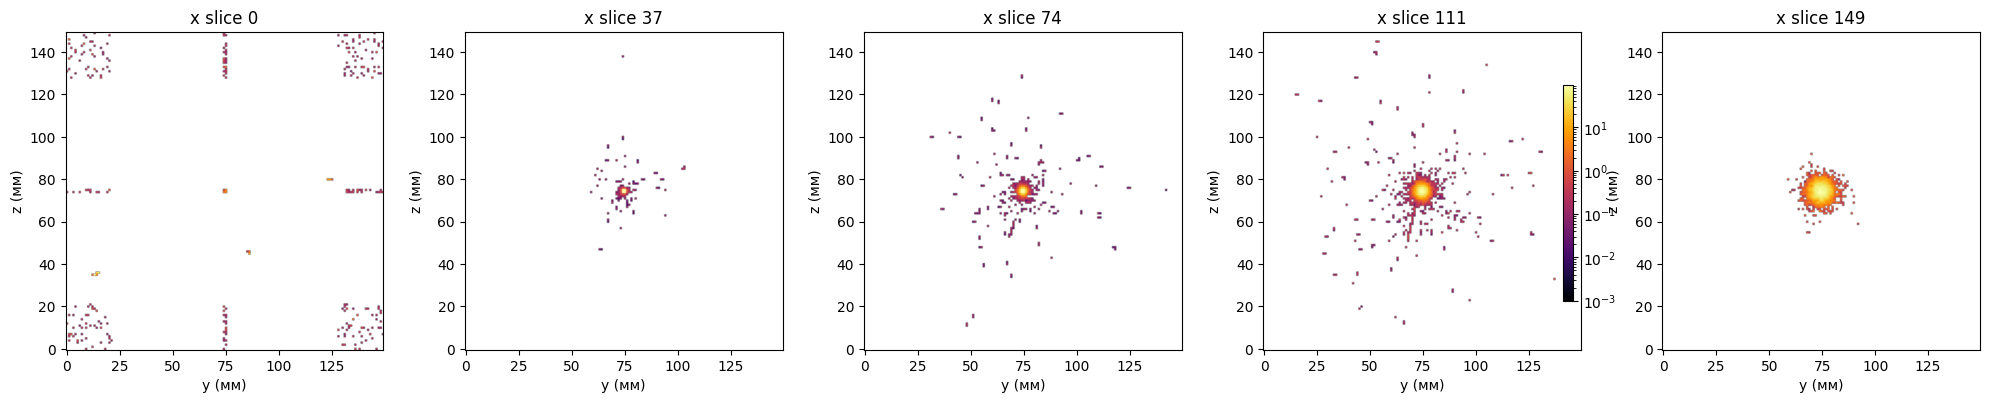

In [28]:
def plot_slices(H, edges, axis='x', num_slices=5):
    axis_map = {'x': 0, 'y': 1, 'z': 2}
    ax_id = axis_map[axis]

    indices = np.linspace(0, H.shape[ax_id] - 1, num_slices, dtype=int)

    fig, axes = plt.subplots(1, num_slices, figsize=(4 * num_slices, 4))

    for i, idx in enumerate(indices):
        if axis == 'x':
            slice_2d = H[idx, :, :]
            xlabel, ylabel = "y (мм)", "z (мм)"
        elif axis == 'y':
            slice_2d = H[:, idx, :]
            xlabel, ylabel = "x (мм)", "z (мм)"
        else:
            slice_2d = H[:, :, idx]
            xlabel, ylabel = "x (мм)", "y (мм)"

        im = axes[i].imshow(
            slice_2d.T,
            origin='lower',
            cmap='inferno',
            norm=plt.cm.colors.LogNorm(vmin=1e-3)
        )

        axes[i].set_title(f"{axis} slice {idx}")
        axes[i].set_xlabel(xlabel)
        axes[i].set_ylabel(ylabel)

    fig.colorbar(im, ax=axes, shrink=0.7)
    plt.tight_layout()
    plt.show()

H_primary, edges = build_voxel_grid(df_primary, bins=(150, 150, 150))

plot_slices(H_primary, edges, axis='x')  # вдоль пучка

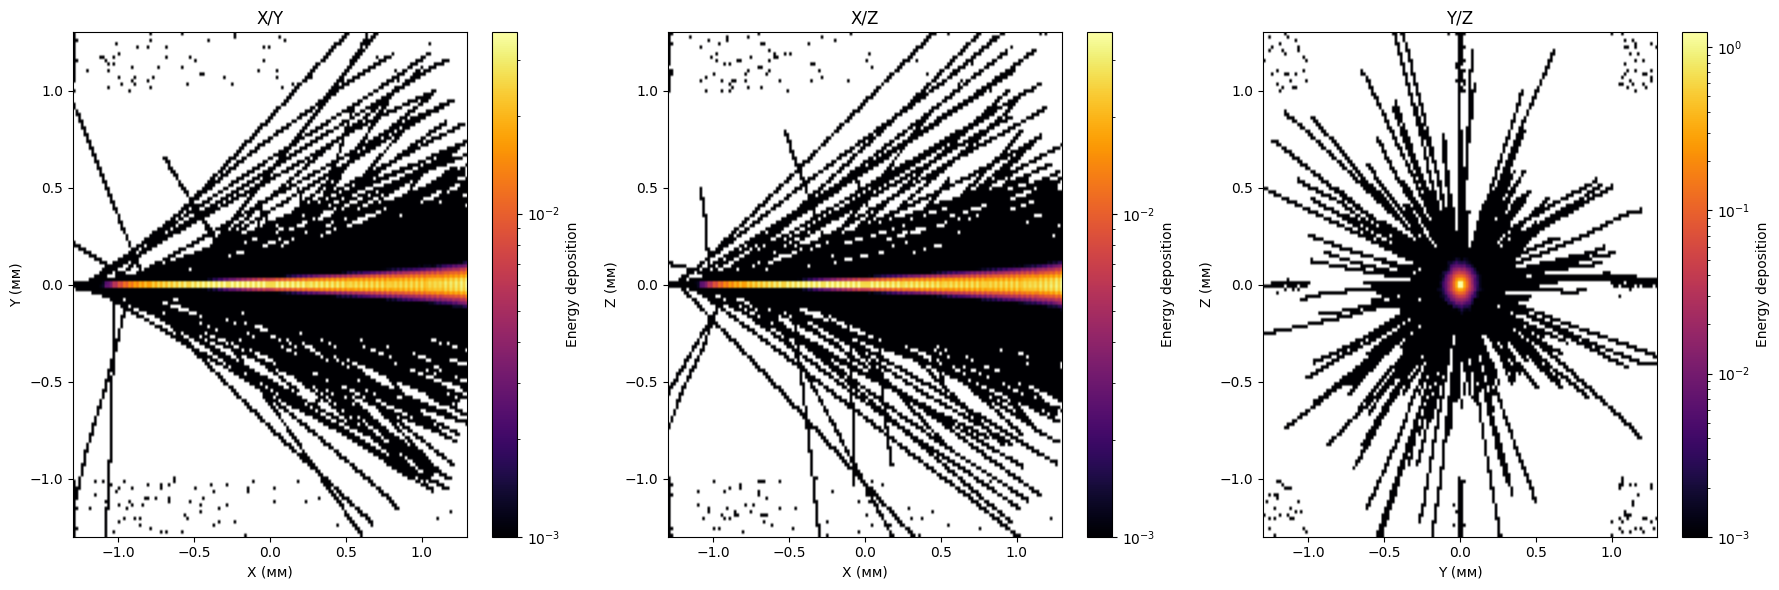

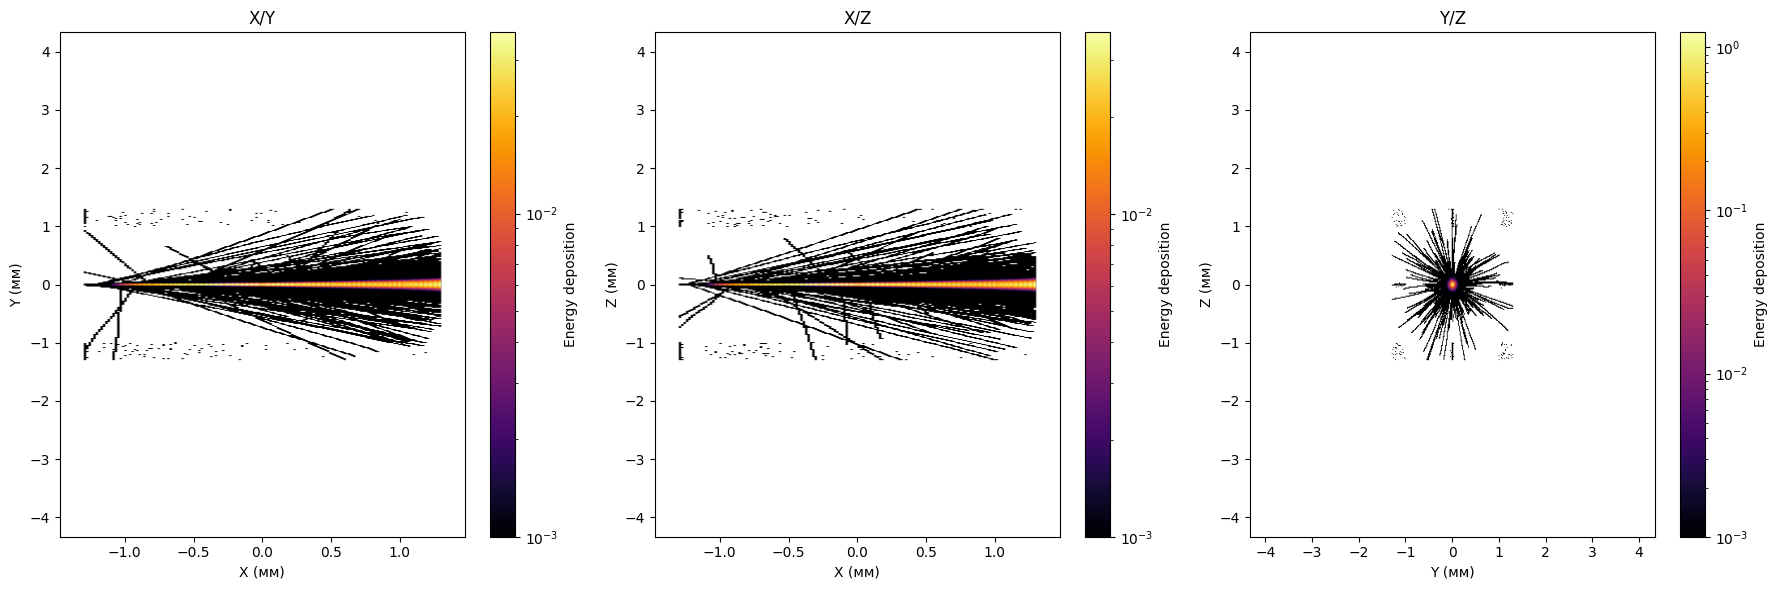

In [4]:
# def plot_projections_from_voxel(H):
#     fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#     projections = [
#         (H.sum(axis=2), "X/Y"),  # интеграция по z
#         (H.sum(axis=1), "X/Z"),  # интеграция по y
#         (H.sum(axis=0), "Y/Z")   # интеграция по x
#     ]

#     for ax, (proj, title) in zip(axes, projections):
#         im = ax.imshow(
#             proj.T,
#             origin='lower',
#             cmap='inferno',
#             norm=plt.cm.colors.LogNorm(vmin=1e-3)
#         )
#         ax.set_title(title)
#         fig.colorbar(im, ax=ax)

#     plt.tight_layout()
#     plt.show()

import matplotlib.pyplot as plt
import numpy as np

def plot_projections_from_voxel(H, edges):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # edges
    x_edges, y_edges, z_edges = edges

    projections = [
        (H.sum(axis=2), "X/Y", x_edges, y_edges),  # интеграция по z
        (H.sum(axis=1), "X/Z", x_edges, z_edges),  # интеграция по y
        (H.sum(axis=0), "Y/Z", y_edges, z_edges)   # интеграция по x
    ]

    for ax, (proj, title, x_e, y_e) in zip(axes, projections):
        im = ax.imshow(
            proj.T,
            origin='lower',
            extent=[x_e[0], x_e[-1], y_e[0], y_e[-1]],
            aspect='auto',
            cmap='inferno',
            norm=plt.cm.colors.LogNorm(vmin=1e-3)
        )

        ax.set_xlabel(f"{title.split('/')[0]} (мм)")
        ax.set_ylabel(f"{title.split('/')[1]} (мм)")
        ax.set_title(title)

        fig.colorbar(im, ax=ax, label="Energy deposition")

    plt.tight_layout()
    plt.show()

H_primary, edges = build_voxel_grid(df_primary, bins=(150, 150, 150))

plot_projections_from_voxel(H_primary, edges)

new_shape = (170, 500, 500)  # сильно расширили по y,z

H_big = pad_voxel_grid(H_primary, new_shape)
edges_big = pad_edges(edges, H_primary.shape, new_shape)

plot_projections_from_voxel(H_big, edges_big)

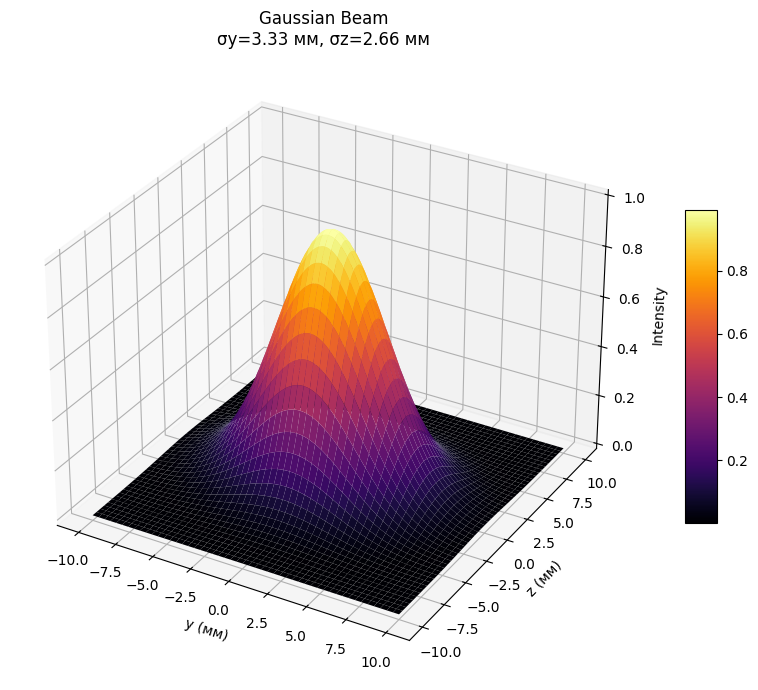

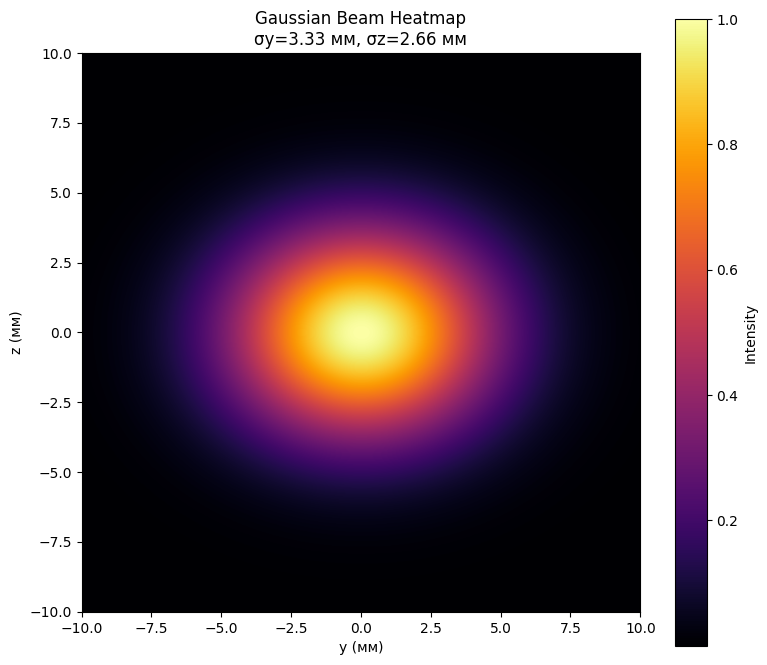

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_gaussian_beam_3d(sigma_y_mm=3.0, sigma_z_mm=3.0, size_mm=20, resolution=200):
    """
    sigma_y_mm, sigma_z_mm — ширина пучка (мм)
    size_mm — размер области визуализации (±size_mm)
    resolution — число точек по каждой оси
    """

    # координатная сетка
    y = np.linspace(-size_mm, size_mm, resolution)
    z = np.linspace(-size_mm, size_mm, resolution)
    Y, Z = np.meshgrid(y, z)

    # Gaussian beam
    I = np.exp(-(Y**2 / (2 * sigma_y_mm**2) + Z**2 / (2 * sigma_z_mm**2)))

    # нормировка (по желанию)
    I /= I.max()

    # 3D plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(
        Y, Z, I,
        cmap='inferno',
        linewidth=0,
        antialiased=True
    )

    ax.set_xlabel("y (мм)")
    ax.set_ylabel("z (мм)")
    ax.set_zlabel("Intensity")
    ax.set_title(f"Gaussian Beam\nσy={sigma_y_mm} мм, σz={sigma_z_mm} мм")

    fig.colorbar(surf, shrink=0.5, aspect=10)

    plt.tight_layout()
    plt.show()

def plot_gaussian_beam_heatmap(sigma_y_mm=3.0,
                               sigma_z_mm=3.0,
                               size_mm=20,
                               resolution=200):
    """
    Визуализация гауссова пучка в виде heatmap.

    sigma_y_mm, sigma_z_mm — ширина пучка (мм)
    size_mm — размер области визуализации (±size_mm)
    resolution — число точек по каждой оси
    """

    # координатная сетка
    y = np.linspace(-size_mm, size_mm, resolution)
    z = np.linspace(-size_mm, size_mm, resolution)
    Y, Z = np.meshgrid(y, z)

    # Gaussian beam
    I = np.exp(
        -(Y**2 / (2 * sigma_y_mm**2) +
          Z**2 / (2 * sigma_z_mm**2))
    )

    # нормировка
    I /= I.max()

    # Heatmap
    plt.figure(figsize=(8, 7))

    im = plt.imshow(
        I,
        extent=[-size_mm, size_mm, -size_mm, size_mm],
        origin='lower',
        cmap='inferno',
        aspect='equal'
    )

    plt.xlabel("y (мм)")
    plt.ylabel("z (мм)")
    plt.title(f"Gaussian Beam Heatmap\nσy={sigma_y_mm} мм, σz={sigma_z_mm} мм")

    cbar = plt.colorbar(im)
    cbar.set_label("Intensity")

    plt.tight_layout()
    plt.show()


plot_gaussian_beam_3d(sigma_y_mm=3.33, sigma_z_mm=2.66, size_mm=10, resolution=800)
plot_gaussian_beam_heatmap(sigma_y_mm=3.33, sigma_z_mm=2.66, size_mm=10, resolution=800)

In [4]:
import torch
import torch.nn.functional as F
import numpy as np

def gaussian_kernel_2d_torch(sigma_y, sigma_z, device):
    # размер ядра (~3 sigma в каждую сторону)
    size_y = int(6 * sigma_y) + 1
    size_z = int(6 * sigma_z) + 1

    y = torch.arange(size_y, device=device) - size_y // 2
    z = torch.arange(size_z, device=device) - size_z // 2

    Y, Z = torch.meshgrid(y, z, indexing='ij')

    kernel = torch.exp(-(Y**2 / (2 * sigma_y**2) + Z**2 / (2 * sigma_z**2)))
    kernel /= kernel.sum()

    return kernel

def apply_gaussian_beam_physical_torch(H, edges, sigma_y_mm, sigma_z_mm, device="cuda"):
    # шаги в мм
    dy = edges[1][1] - edges[1][0]
    dz = edges[2][1] - edges[2][0]

    # перевод в воксели
    sigma_y = sigma_y_mm / dy
    sigma_z = sigma_z_mm / dz

    # numpy → torch
    H_torch = torch.from_numpy(H).float().to(device)

    # добавляем channel dimension: (N, C, H, W)
    # N = x (глубина)
    H_torch = H_torch.unsqueeze(1)  # (nx, 1, ny, nz)

    # kernel
    kernel = gaussian_kernel_2d_torch(sigma_y, sigma_z, device)
    kernel = kernel.unsqueeze(0).unsqueeze(0)  # (1,1,ky,kz)

    # padding = "same"
    pad_y = kernel.shape[2] // 2
    pad_z = kernel.shape[3] // 2

    # свёртка
    H_blurred = F.conv2d(
        H_torch,
        kernel,
        padding=(pad_y, pad_z)
    )

    # обратно в numpy
    H_blurred = H_blurred.squeeze(1).cpu().numpy()

    return H_blurred

e_charge = 1.602e-19  # Кл

def apply_beam_current(H_beam, current_A):
    N_per_sec = current_A / e_charge
    return H_beam * N_per_sec

H_primary, edges = build_voxel_grid(df_primary, bins=(150, 150, 150))
H_blurred = apply_gaussian_beam_physical_torch(
    H_primary,
    edges,
    sigma_y_mm=0.2,
    sigma_z_mm=0.2,
    device="cpu"
)
H_power = apply_beam_current(H_blurred, current_A=1e-6)  # 1 μA
plot_projections_from_voxel(H_power, edges)

new_shape = (160, 1000, 1000)  # сильно расширили по y,z
H_big = pad_voxel_grid(H_primary, new_shape)
edges_big = pad_edges(edges, H_primary.shape, new_shape)
H_blurred = apply_gaussian_beam_physical_torch(
    H_big,
    edges_big,
    sigma_y_mm=1.5,
    sigma_z_mm=1.5,
    device="cpu"
)
H_power = apply_beam_current(H_blurred, current_A=1e-6)  # 1 μA
plot_projections_from_voxel(H_power, edges_big)

: 

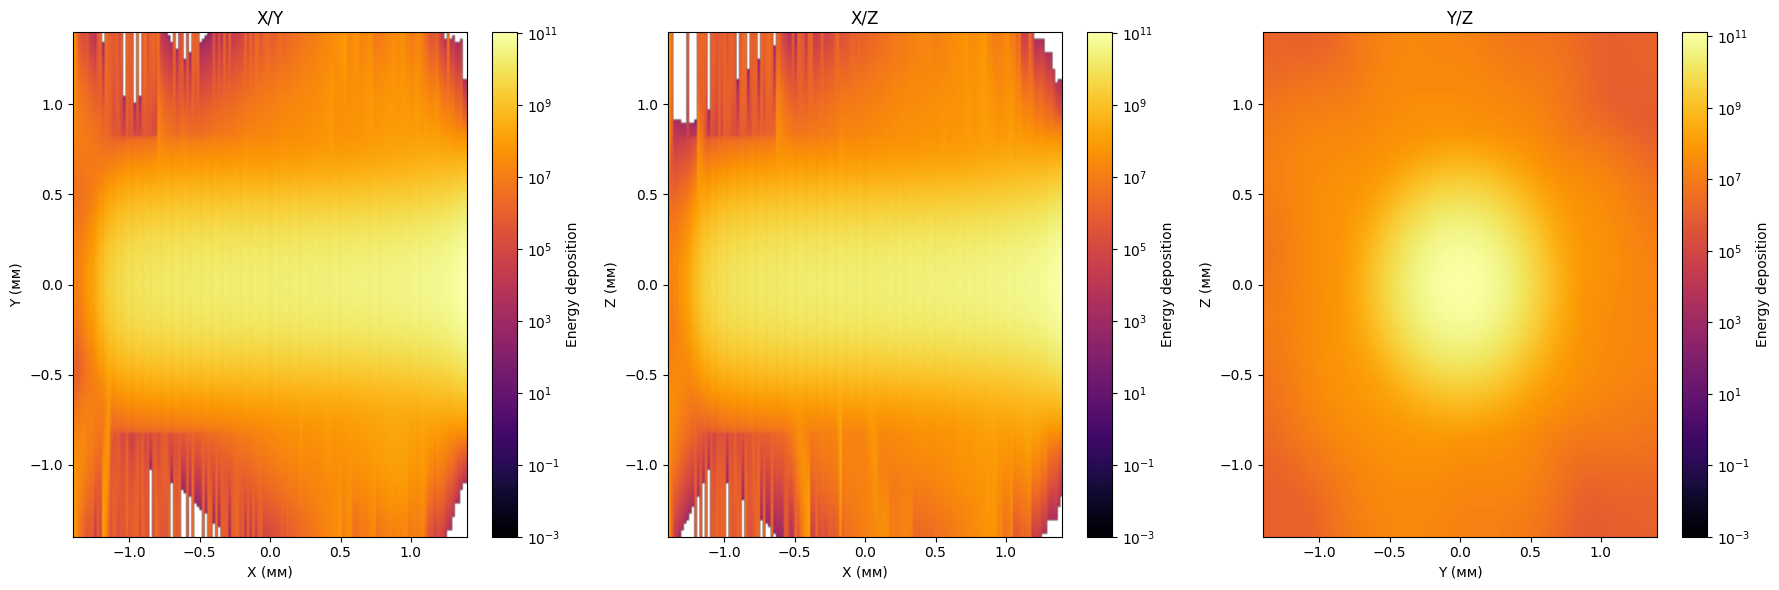

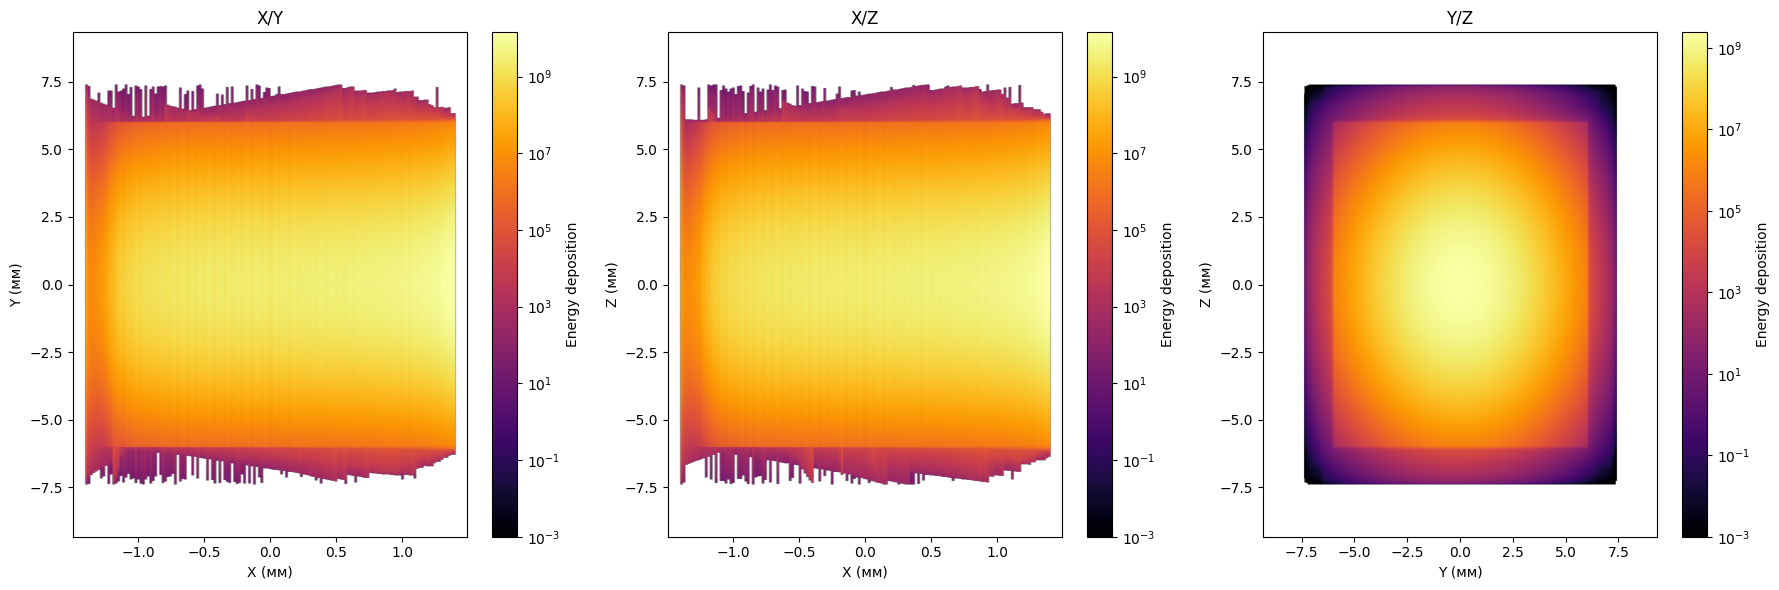

In [5]:
from scipy.ndimage import gaussian_filter

def apply_gaussian_beam_physical(H, edges, sigma_y_mm, sigma_z_mm):
    dy = edges[1][1] - edges[1][0]
    dz = edges[2][1] - edges[2][0]

    sigma_y = sigma_y_mm / dy
    sigma_z = sigma_z_mm / dz

    H_blurred = np.zeros_like(H)

    for i in range(H.shape[0]):  # по x
        H_blurred[i] = gaussian_filter(
            H[i],
            sigma=(sigma_y, sigma_z)
        )

    return H_blurred

e_charge = 1.602e-19  # Кл

def apply_beam_current(H_beam, current_A):
    N_per_sec = current_A / e_charge
    return H_beam * N_per_sec

H_primary, edges = build_voxel_grid(df_primary, bins=(150, 150, 150))
H_blurred = apply_gaussian_beam_physical(H_primary, edges, 0.2, 0.2)
H_power = apply_beam_current(H_blurred, current_A=1e-6)  # 1 μA
plot_projections_from_voxel(H_power, edges)

new_shape = (160, 1000, 1000)  # сильно расширили по y,z
H_big = pad_voxel_grid(H_primary, new_shape)
edges_big = pad_edges(edges, H_primary.shape, new_shape)
H_blurred = apply_gaussian_beam_physical(H_big, edges_big, 1.5, 1.5)
H_power = apply_beam_current(H_blurred, current_A=1e-6)  # 1 μA
plot_projections_from_voxel(H_power, edges_big)

Before: 97672753186117.81
After: 97672753186118.03


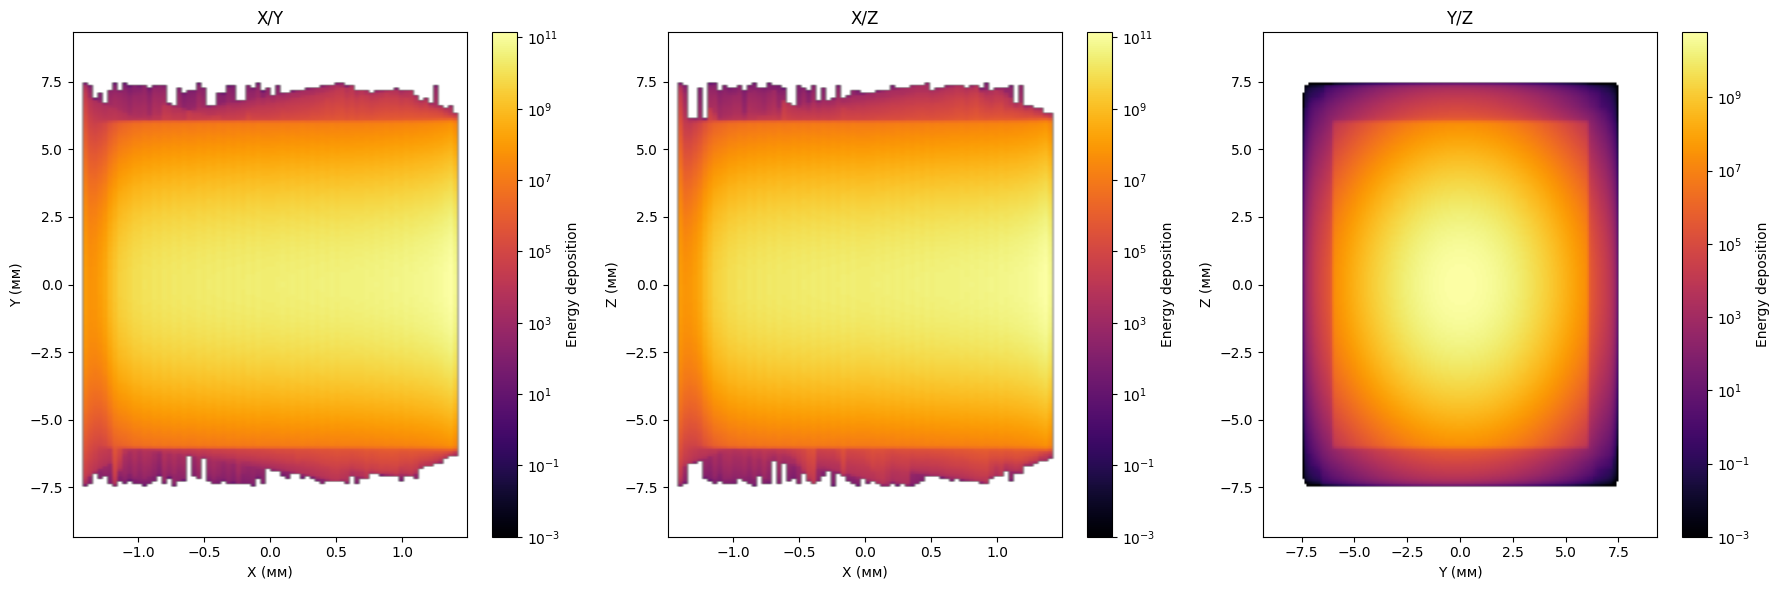

In [7]:
def downsample_voxel_grid(H, factors):
    """
    factors = (fx, fy, fz) — во сколько раз уменьшаем
    """
    fx, fy, fz = factors
    nx, ny, nz = H.shape

    # обрезаем чтобы делилось
    nx_new = (nx // fx) * fx
    ny_new = (ny // fy) * fy
    nz_new = (nz // fz) * fz

    H_cropped = H[:nx_new, :ny_new, :nz_new]

    # reshape + суммирование
    H_down = H_cropped.reshape(
        nx_new // fx, fx,
        ny_new // fy, fy,
        nz_new // fz, fz
    ).sum(axis=(1, 3, 5))

    return H_down

def downsample_edges(edges, factors):
    fx, fy, fz = factors

    edges_x = edges[0][::fx]
    edges_y = edges[1][::fy]
    edges_z = edges[2][::fz]

    return (edges_x, edges_y, edges_z)

H_small = downsample_voxel_grid(H_power, (2, 5, 5))
edges_small = downsample_edges(edges_big, (2, 5, 5))

print("Before:", H_power.sum())
print("After:", H_small.sum())

plot_projections_from_voxel(H_small, edges_small)

=== gaussian_filter ===


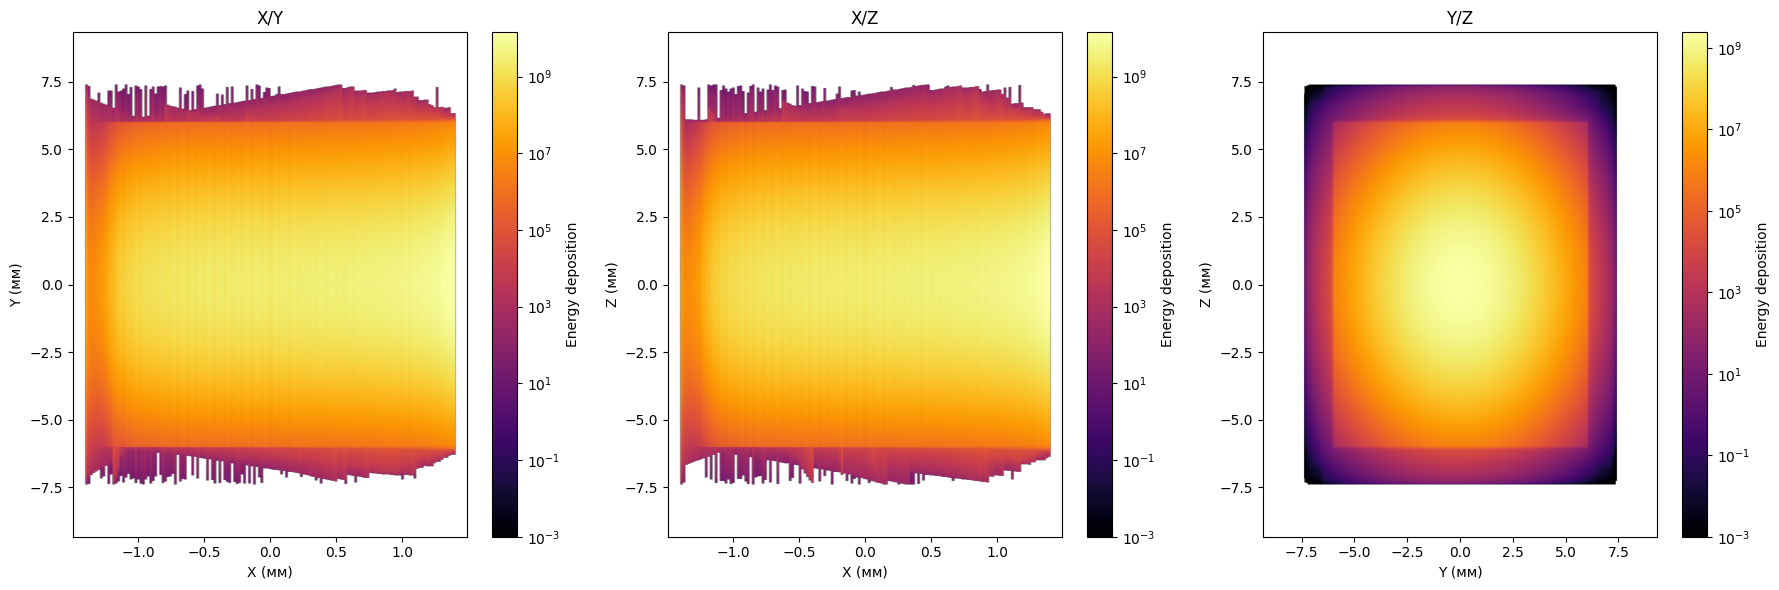

=== FFT ===


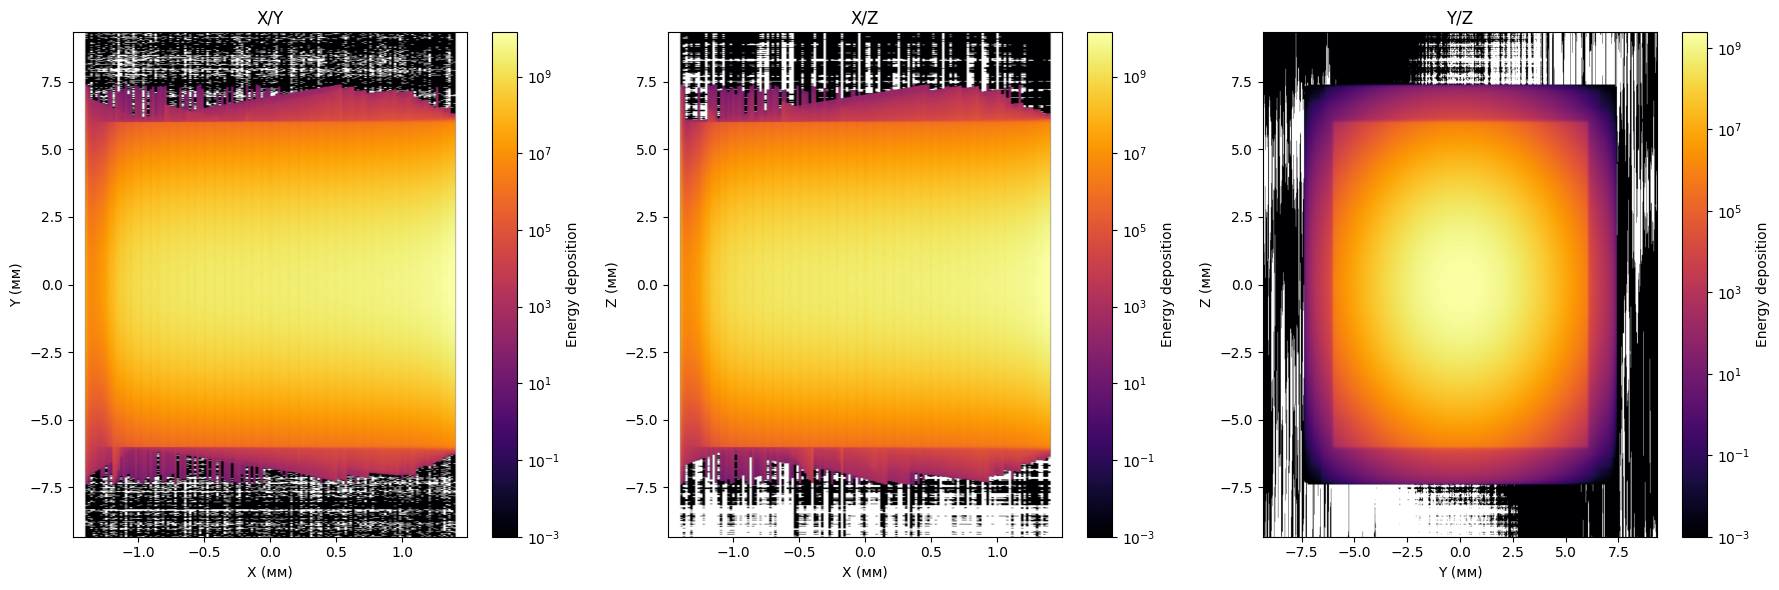

In [11]:
import numpy as np
from scipy.signal import fftconvolve
from scipy.ndimage import gaussian_filter

def apply_gaussian_beam_physical(H, edges, sigma_y_mm, sigma_z_mm):
    dy = edges[1][1] - edges[1][0]
    dz = edges[2][1] - edges[2][0]

    sigma_y = sigma_y_mm / dy
    sigma_z = sigma_z_mm / dz

    H_blurred = np.zeros_like(H)

    for i in range(H.shape[0]):  # по x
        H_blurred[i] = gaussian_filter(
            H[i],
            sigma=(sigma_y, sigma_z)
        )

    return H_blurred

def make_gaussian_kernel(edges, sigma_y_mm, sigma_z_mm, truncate=4.0):
    dy = edges[1][1] - edges[1][0]
    dz = edges[2][1] - edges[2][0]

    sigma_y = sigma_y_mm / dy
    sigma_z = sigma_z_mm / dz

    # размер ядра (обрезаем на truncate * sigma)
    half_size_y = int(truncate * sigma_y)
    half_size_z = int(truncate * sigma_z)

    y = np.arange(-half_size_y, half_size_y + 1)
    z = np.arange(-half_size_z, half_size_z + 1)

    Y, Z = np.meshgrid(y, z, indexing='ij')

    kernel = np.exp(
        -0.5 * ((Y / sigma_y) ** 2 + (Z / sigma_z) ** 2)
    )

    # нормировка (важно!)
    kernel /= np.sum(kernel)

    return kernel


def apply_gaussian_beam_fft(H, edges, sigma_y_mm, sigma_z_mm):
    kernel = make_gaussian_kernel(edges, sigma_y_mm, sigma_z_mm)

    H_blurred = np.zeros_like(H)

    for i in range(H.shape[0]):  # по x
        H_blurred[i] = fftconvolve(
            H[i],
            kernel,
            mode='same'   # сохраняем размер
        )

    return H_blurred

e_charge = 1.602e-19  # Кл

def apply_beam_current(H_beam, current_A):
    N_per_sec = current_A / e_charge
    return H_beam * N_per_sec

H_primary, edges = build_voxel_grid(df_primary, bins=(150, 150, 150))
new_shape = (160, 1000, 1000)  # сильно расширили по y,z
H_big = pad_voxel_grid(H_primary, new_shape)
edges_big = pad_edges(edges, H_primary.shape, new_shape)

# === ТВОЙ gaussian_filter ===
H_blurred_gauss = apply_gaussian_beam_physical(H_big, edges_big, 1.5, 1.5)

# === FFT версия ===
H_blurred_fft = apply_gaussian_beam_fft(H_big, edges_big, 1.5, 1.5)

# ток
H_power_gauss = apply_beam_current(H_blurred_gauss, current_A=1e-6)
H_power_fft   = apply_beam_current(H_blurred_fft,   current_A=1e-6)

# визуализация
print("=== gaussian_filter ===")
plot_projections_from_voxel(H_power_gauss, edges_big)

print("=== FFT ===")
plot_projections_from_voxel(H_power_fft, edges_big)

Before: 97672753186117.81
After: 97672753186118.03


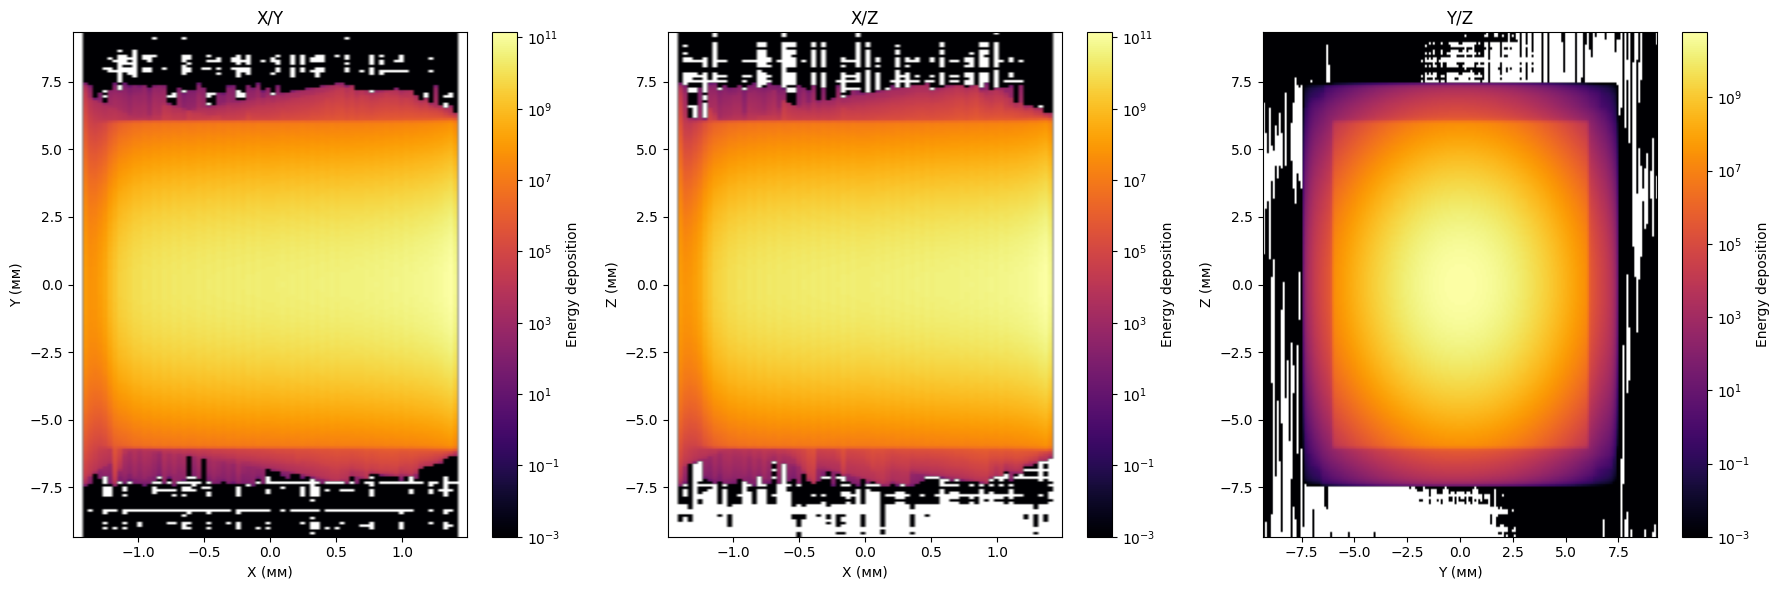

In [12]:
H_small = downsample_voxel_grid(H_power_fft, (2, 5, 5))
edges_small = downsample_edges(edges_big, (2, 5, 5))

print("Before:", H_power.sum())
print("After:", H_small.sum())

plot_projections_from_voxel(H_small, edges_small)

In [8]:
import numpy as np
import plotly.graph_objects as go

def save_3d_volume_html(H, edges, filename="beam.html",
                       isomin=None, isomax=None, surface_count=5):
    nx, ny, nz = H.shape

    x = np.linspace(edges[0][0], edges[0][-1], nx)
    y = np.linspace(edges[1][0], edges[1][-1], ny)
    z = np.linspace(edges[2][0], edges[2][-1], nz)

    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

    values = H.flatten()

    # авто-порог если не задан
    if isomin is None:
        isomin = values.max() * 0.05
    if isomax is None:
        isomax = values.max()

    fig = go.Figure(data=go.Isosurface(
        x=X.flatten(),
        y=Y.flatten(),
        z=Z.flatten(),
        value=values,
        isomin=isomin,
        isomax=isomax,
        surface_count=surface_count,
    ))

    fig.update_layout(
        title="3D Beam",
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        )
    )

    fig.write_html(filename)
    print(f"Saved to {filename}")

save_3d_volume_html(H_small, edges_small, filename="beam.html")

Saved to beam.html


In [13]:
def cut_half_y(H, edges):
    y_edges = edges[1]

    # индекс, где y >= 0
    idx = np.searchsorted(y_edges, 0)

    # обрезаем
    H_half = H[:, idx:, :]
    edges_half = (
        edges[0],
        edges[1][idx:],
        edges[2]
    )

    return H_half, edges_half

H_half, edges_half = cut_half_y(H_small, edges_small)

save_3d_volume_html(H_half, edges_half, "beam_fft_half.html")

Saved to beam_fft_half.html


Загружено 4,121,952 точек из 1 треков


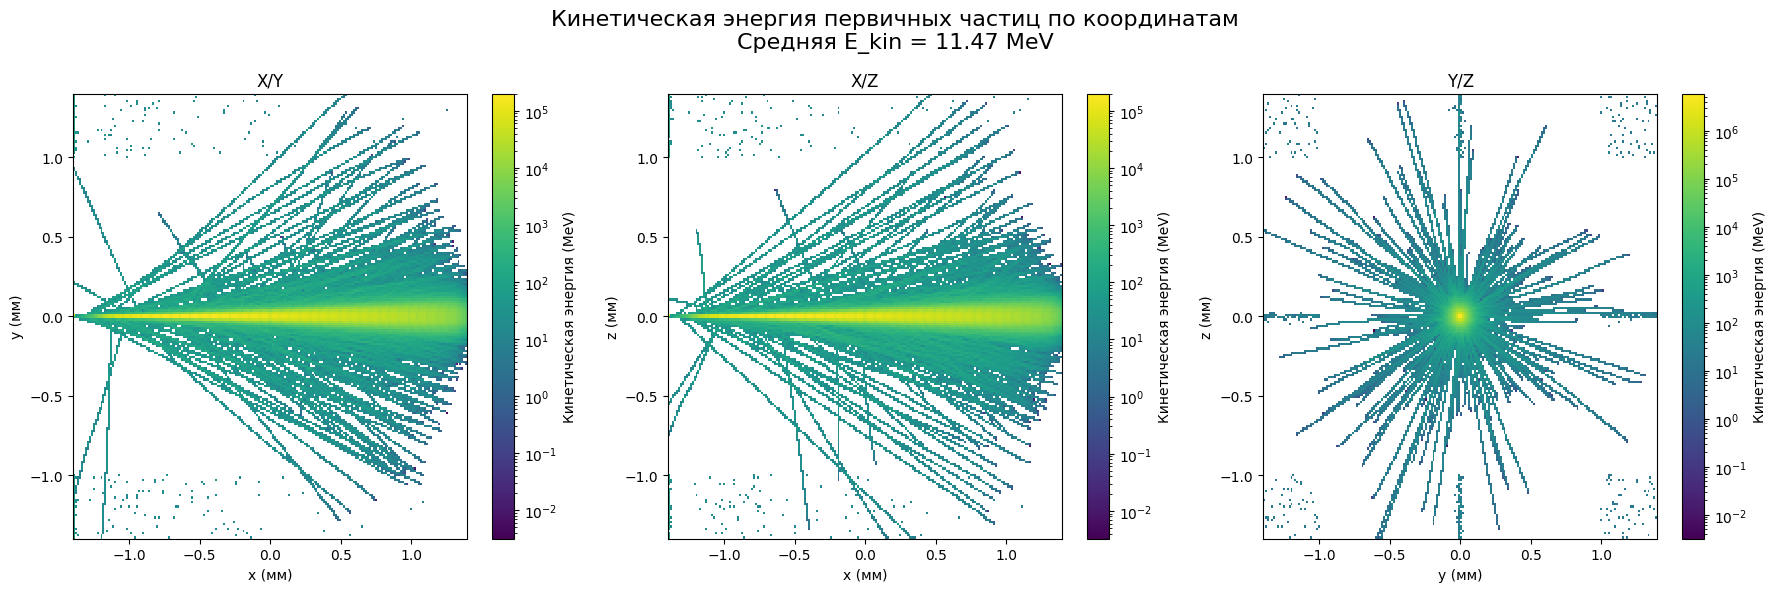

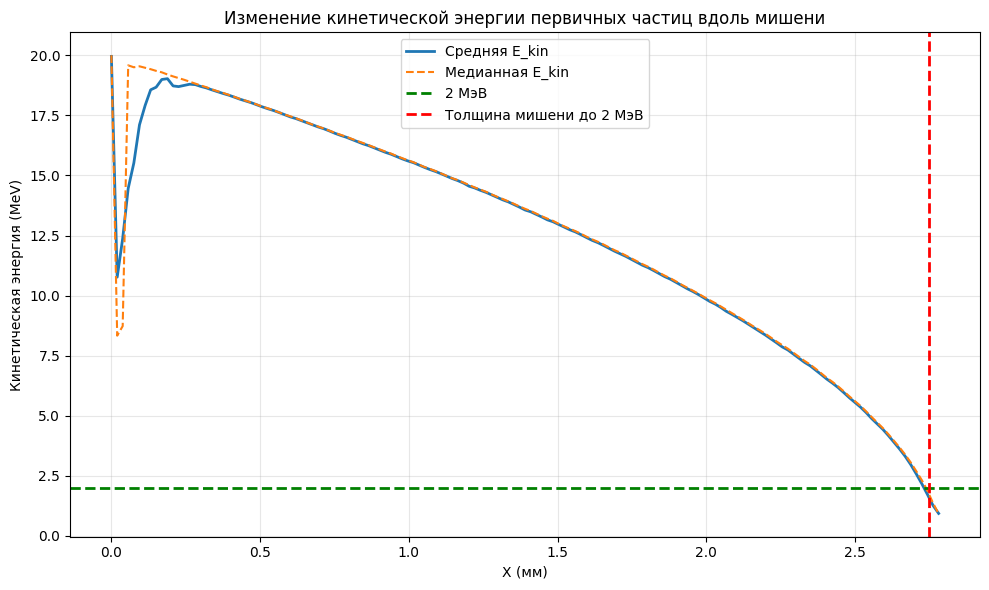

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("Full traks/kinetic_primary_points_20_MeV.csv")

print(f"Загружено {len(df):,} точек из {df['track_id'].nunique() if 'track_id' in df.columns else 1} треков")

# ====================== 2D ТЕПЛОВЫЕ КАРТЫ КИНЕТИЧЕСКОЙ ЭНЕРГИИ ======================

def plot_kinetic_heatmaps(df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("Кинетическая энергия первичных частиц по координатам\n"
        f"Средняя E_kin = {df['kinetic_energy_mev'].mean():.2f} MeV",
        fontsize=16,
    )

    projections = [("x_mm", "y_mm", "X/Y"),
                   ("x_mm", "z_mm", "X/Z"),
                   ("y_mm", "z_mm", "Y/Z")]

    for ax, (colx, coly, proj) in zip(axes, projections):
        x = df[colx]
        y = df[coly]
        weights = df["kinetic_energy_mev"]

        h = ax.hist2d(x, y, bins=200, weights=weights, cmap='viridis', norm='log')

        ax.set_xlabel(colx.replace("_mm", " (мм)"))
        ax.set_ylabel(coly.replace("_mm", " (мм)"))
        ax.set_title(proj)
        fig.colorbar(h[3], ax=ax, label='Кинетическая энергия (MeV)')

    plt.tight_layout()
    plt.show()

plot_kinetic_heatmaps(df)

# ====================== ПРОФИЛЬ ПО X ======================

# Биннинг по X
x_bins = np.linspace(df['x_mm'].min(), df['x_mm'].max(), 150)
df['x_bin'] = pd.cut(df['x_mm'], bins=x_bins, include_lowest=True)

profile = df.groupby('x_bin', observed=True).agg(
    mean_kinetic=('kinetic_energy_mev', 'mean'),
    median_kinetic=('kinetic_energy_mev', 'median'),
    max_kinetic=('kinetic_energy_mev', 'max'),
    total_edep=('energy_deposition_mev', 'sum'),
    point_count=('x_mm', 'size')
).reset_index()

profile['x_mm_center'] = profile['x_bin'].apply(lambda x: x.mid)

plt.figure(figsize=(10, 6))
plt.plot(profile['x_mm_center'].to_list() - profile['x_mm_center'][0], profile['mean_kinetic'], label='Средняя E_kin', linewidth=2)
plt.plot(profile['x_mm_center'].to_list() - profile['x_mm_center'][0], profile['median_kinetic'], '--', label='Медианная E_kin')
plt.axhline(y=2.0, linestyle='--', linewidth=2, label='2 МэВ', color='green')
plt.axvline(x=2.75, linestyle='--', linewidth=2, label='Толщина мишени до 2 МэВ', color='red')
plt.xlabel('X (мм)')
plt.ylabel('Кинетическая энергия (MeV)')
plt.title('Изменение кинетической энергии первичных частиц вдоль мишени')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [2]:
x = profile['x_mm_center'].to_list() - profile['x_mm_center'][0]
y = profile['mean_kinetic']

for xi, yi in zip(x, y):
    if xi > 1.1:
        print(yi)
        break

4.192164855597681


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Full traks/kinetic_primary_points_20_MeV.csv")

# === 1. Сдвиг оси X в начало мишени (очень важно!) ===
x_min = df['x_mm'].min()                    # примерно -0.7499
df['x_mm_shifted'] = df['x_mm'] - x_min     # теперь от 0 до ~1.2924 мм

print(f"Диапазон X после сдвига: 0 — {df['x_mm_shifted'].max():.4f} мм")

# ====================== ПРОФИЛЬ ПО X (со сдвигом) ======================
x_bins = np.linspace(0, df['x_mm_shifted'].max(), 200)   # больше бинов = точнее
df['x_bin'] = pd.cut(df['x_mm_shifted'], bins=x_bins, include_lowest=True)

profile = df.groupby('x_bin', observed=True).agg(
    mean_kinetic=('kinetic_energy_mev', 'mean'),
    median_kinetic=('kinetic_energy_mev', 'median'),
    point_count=('x_mm_shifted', 'size')
).reset_index()

profile['x_mm_center'] = profile['x_bin'].apply(lambda x: x.mid)

# === ПОИСК УЧАСТКА, ГДЕ СРЕДНЯЯ КИНЕТИЧЕСКАЯ ЭНЕРГИЯ ВПЕРВЫЕ МЕНЬШЕ 2 MeV ===
below_2 = profile[profile['mean_kinetic'] < 2.0]

if not below_2.empty:
    first_point = below_2.iloc[0]
    distance = first_point['x_mm_center']
    energy_there = first_point['mean_kinetic']

    print("РЕЗУЛЬТАТ:")
    print("→ Кинетическая энергия первичных частиц стала меньше 2.0 MeV")
    print(f"   на расстоянии **{distance:.4f} мм** от начала мишени")
    print(f"   (средняя E_kin в этой точке ≈ {energy_there:.3f} MeV)")

    # Дополнительно
    below_1 = profile[profile['mean_kinetic'] < 1.0]
    if not below_1.empty:
        print(f"→ До 1 MeV энергия падает на {below_1.iloc[0]['x_mm_center']:.4f} мм")

    remaining = df['x_mm_shifted'].max() - distance
    print(f"→ После этой точки осталось {remaining:.4f} мм мишени")
else:
    print("На всей длине мишени средняя кинетическая энергия первичных частиц не опускается ниже 2 MeV.")


Диапазон X после сдвига: 0 — 2.8000 мм
РЕЗУЛЬТАТ:
→ Кинетическая энергия первичных частиц стала меньше 2.0 MeV
   на расстоянии **2.7510 мм** от начала мишени
   (средняя E_kin в этой точке ≈ 1.792 MeV)
→ До 1 MeV энергия падает на 2.7930 мм
→ После этой точки осталось 0.0490 мм мишени


100 100


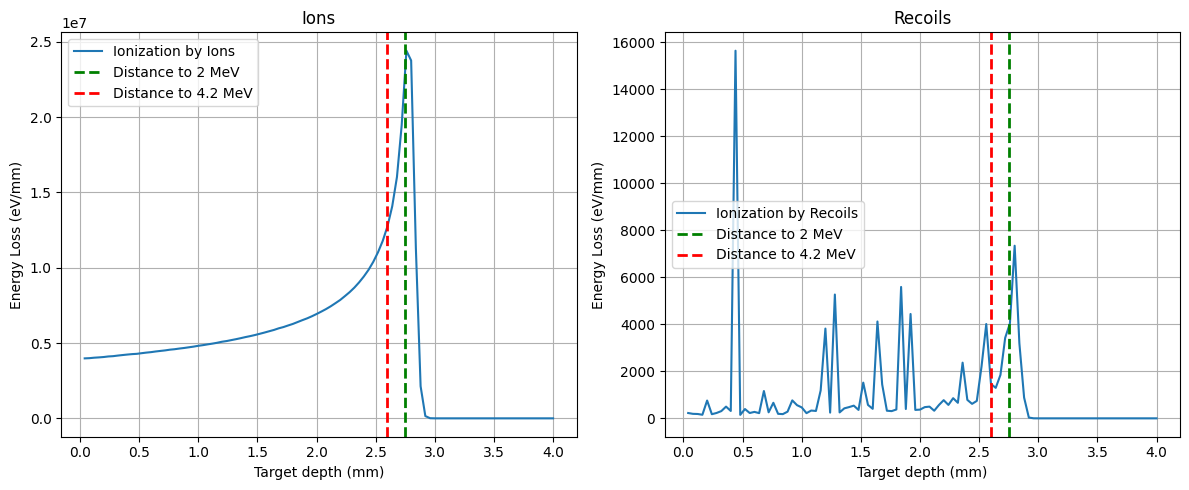

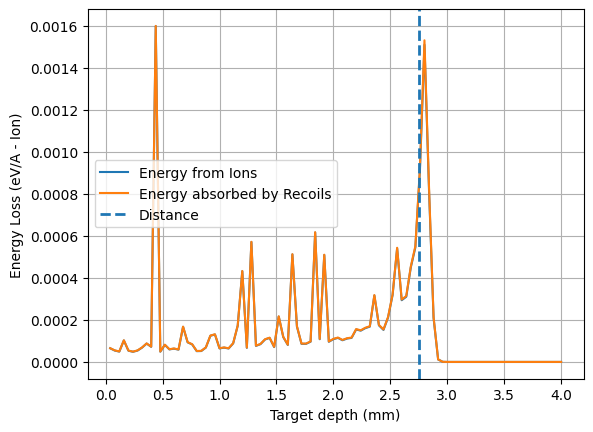

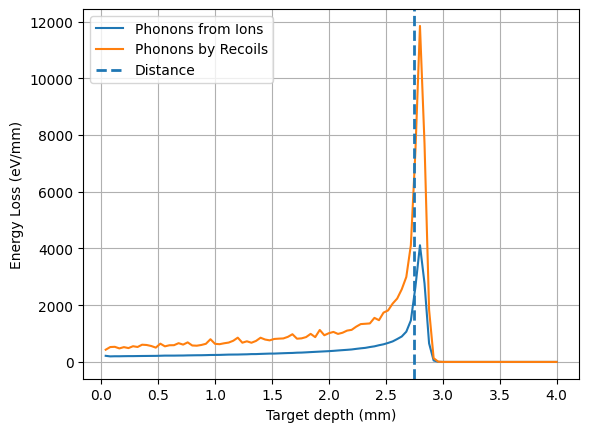

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def is_number(s):
    try:
        float(s.replace('E', 'e'))
        return True
    except:
        return False


def read_srim_table(filename):
    depth, col1, col2 = [], [], []

    with open(filename, 'r') as f:
        lines = f.readlines()

    start_idx = None

    # ищем первую строку, которая реально содержит числа таблицы
    for i, line in enumerate(lines):
        parts = line.split()

        if len(parts) >= 3 and all(is_number(p) for p in parts[:3]):
            start_idx = i
            break

    if start_idx is None:
        raise ValueError(f"Не удалось найти начало таблицы в {filename}")

    # читаем таблицу
    for line in lines[start_idx:]:
        parts = line.split()

        if len(parts) < 3:
            break

        if not all(is_number(p) for p in parts[:3]):
            break

        depth.append(float(parts[0].replace('E', 'e')))
        col1.append(float(parts[1].replace('E', 'e')))
        col2.append(float(parts[2].replace('E', 'e')))

    return np.array(depth), np.array(col1), np.array(col2)


# === чтение ===
depth_ion, ion_ions, ion_recoils = read_srim_table('SRIM_RESULTS_Be/Be_protons20MeV/IONIZ.txt')
depth_rec, rec_ions, rec_abs = read_srim_table('SRIM_RESULTS_Be/Be_protons20MeV/E2RECOIL.txt')
depth_phon, phon_ions, phon_recoils = read_srim_table('SRIM_RESULTS_Be/Be_protons20MeV/PHONON.txt')


print(len(depth_ion), len(depth_rec))  # проверка

fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 строка, 2 графика

# --- Первый график ---
axs[0].plot(depth_ion * 10**-7, ion_ions * 10**7, label='Ionization by Ions')
axs[0].axvline(x=2.75, linestyle='--', linewidth=2, label='Distance to 2 MeV', color='green')
axs[0].axvline(x=2.6, linestyle='--', linewidth=2, label='Distance to 4.2 MeV', color='red')

axs[0].set_xlabel('Target depth (mm)')
axs[0].set_ylabel('Energy Loss (eV/mm)')
axs[0].set_title('Ions')
axs[0].legend()
axs[0].grid()

# --- Второй график ---
axs[1].plot(depth_ion * 10**-7, ion_recoils * 10**7, label='Ionization by Recoils')
axs[1].axvline(x=2.75, linestyle='--', linewidth=2, label='Distance to 2 MeV', color='green')
axs[1].axvline(x=2.6, linestyle='--', linewidth=2, label='Distance to 4.2 MeV', color='red')

axs[1].set_xlabel('Target depth (mm)')
axs[1].set_ylabel('Energy Loss (eV/mm)')
axs[1].set_title('Recoils')
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()

plt.figure()
plt.plot(depth_rec * 10**-7, rec_ions, label='Energy from Ions')
plt.plot(depth_rec * 10**-7, rec_abs, label='Energy absorbed by Recoils')

plt.axvline(x=distance, linestyle='--', linewidth=2, label='Distance')

plt.xlabel('Target depth (mm)')
plt.ylabel('Energy Loss (eV/A - Ion)')

plt.legend()
plt.grid()

plt.show()

plt.figure()
plt.plot(depth_phon * 10**-7, phon_ions * 10**7, label='Phonons from Ions')
plt.plot(depth_phon * 10**-7, phon_recoils * 10**7, label='Phonons by Recoils')

plt.axvline(x=distance, linestyle='--', linewidth=2, label='Distance')

plt.xlabel('Target depth (mm)')
plt.ylabel('Energy Loss (eV/mm)')

plt.legend()
plt.grid()

plt.show()

Нейтронов: 181 точек из 5 треков


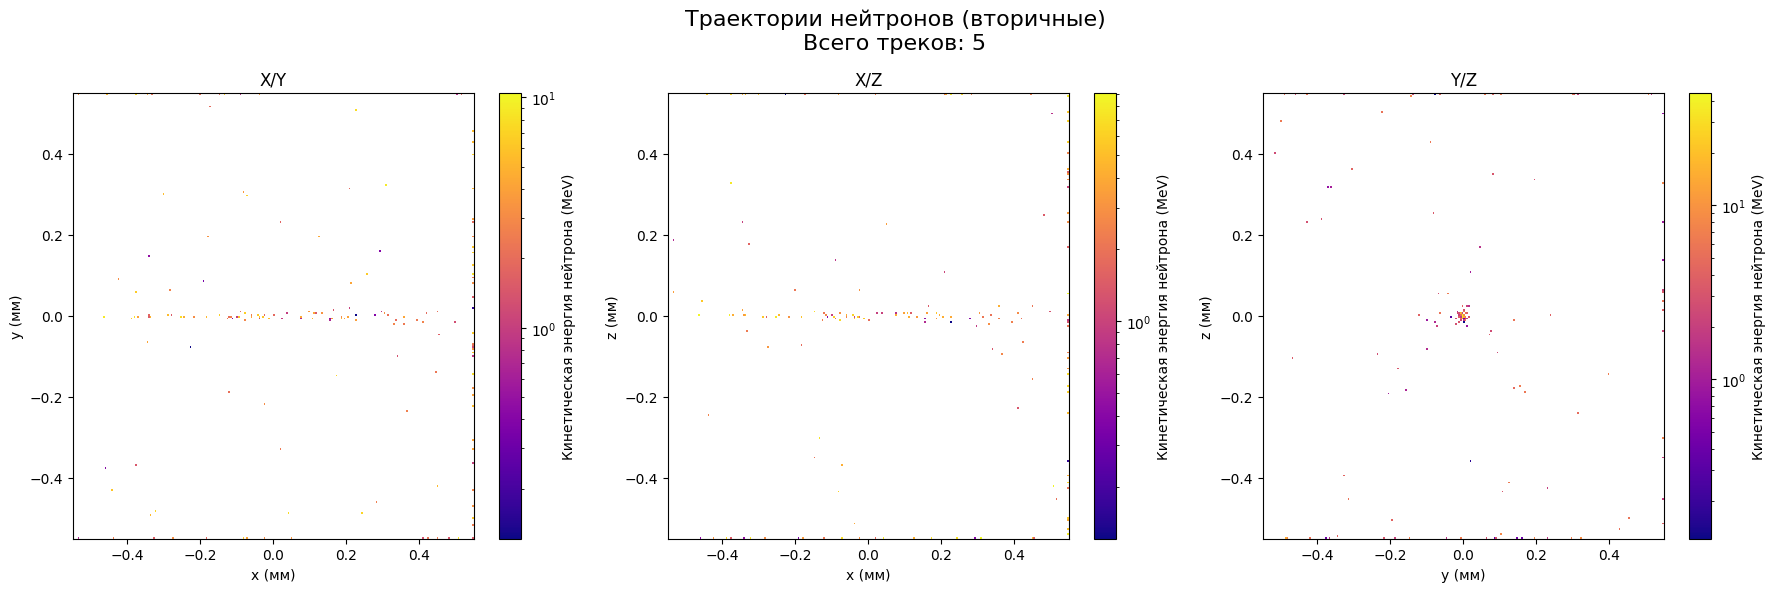

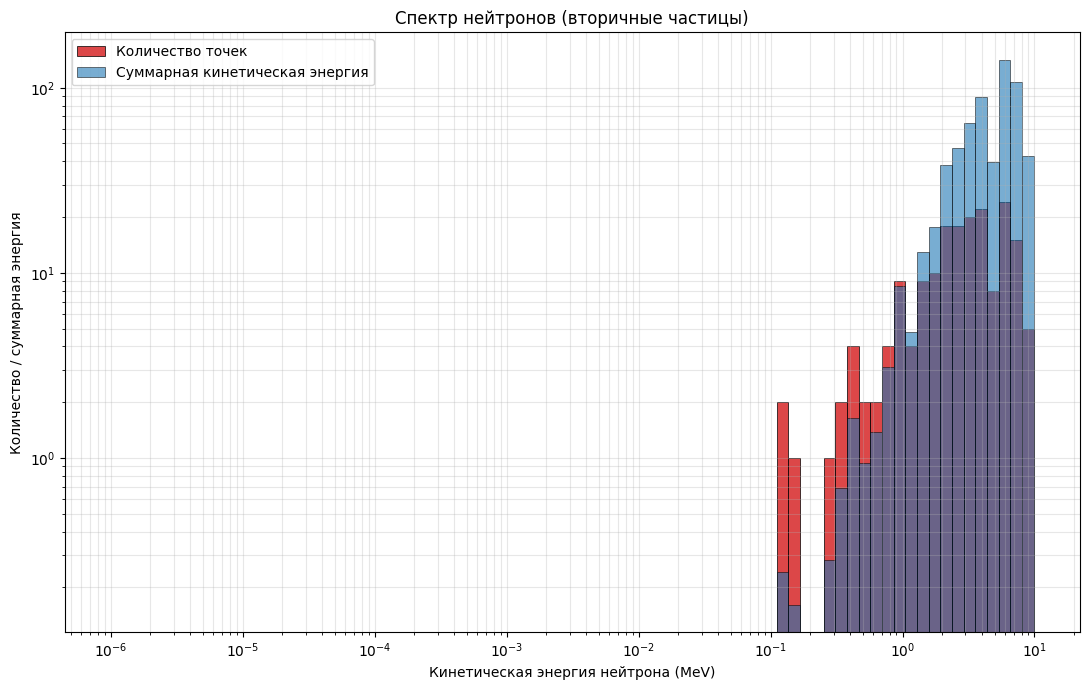

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_neutron = pd.read_csv("Effective traks/neutron_spectrum_13_MeV.csv")   # ваш сохранённый файл

print(
    f"Нейтронов: {len(df_neutron):,} точек из "
    f"{df_neutron['track_id'].nunique() if 'track_id' in df_neutron.columns else 1} треков"
)

# ====================== 2D ТЕПЛОВЫЕ КАРТЫ КИНЕТИЧЕСКОЙ ЭНЕРГИИ НЕЙТРОНОВ ======================
def plot_neutron_heatmaps(df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
    f"Траектории нейтронов (вторичные)\nВсего треков: {df['track_id'].nunique()}",
    fontsize=16,
    )

    projections = [("x_mm", "y_mm", "X/Y"),
                    ("x_mm", "z_mm", "X/Z"),
                    ("y_mm", "z_mm", "Y/Z")]

    for ax, (colx, coly, proj) in zip(axes, projections):
        x = df[colx]
        y = df[coly]
        weights = df["kinetic_energy_mev"]   # можно использовать и 1 для просто плотности треков

        h = ax.hist2d(x, y, bins=250, weights=weights, cmap='plasma', norm=plt.cm.colors.LogNorm())

        ax.set_xlabel(colx.replace("_mm", " (мм)"))
        ax.set_ylabel(coly.replace("_mm", " (мм)"))
        ax.set_title(proj)
        fig.colorbar(h[3], ax=ax, label='Кинетическая энергия нейтрона (MeV)')

    plt.tight_layout()
    plt.show()

plot_neutron_heatmaps(df_neutron)

# ====================== СПЕКТР КИНЕТИЧЕСКОЙ ЭНЕРГИИ НЕЙТРОНОВ ======================

# Логарифмические бины (нейтроны часто имеют широкий диапазон энергий)
e_min = df_neutron['kinetic_energy_mev'].min()
e_max = df_neutron['kinetic_energy_mev'].max()
bins = np.logspace(np.log10(max(e_min, 1e-6)), np.log10(e_max * 1.1), 80)

plt.figure(figsize=(11, 7))

# Гистограмма спектра (по количеству точек)
plt.hist(
    df_neutron['kinetic_energy_mev'],
    bins=bins,
    color='#d62728', alpha=0.85, edgecolor='black', linewidth=0.6,
    label='Количество точек'
)

# Гистограмма по суммарной энергии (опционально)
plt.hist(
    df_neutron['kinetic_energy_mev'],
    bins=bins,
    weights=df_neutron['kinetic_energy_mev'],
    color='#1f77b4', alpha=0.6, edgecolor='black', linewidth=0.6,
    label='Суммарная кинетическая энергия'
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Кинетическая энергия нейтрона (MeV)')
plt.ylabel('Количество / суммарная энергия')
plt.title('Спектр нейтронов (вторичные частицы)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Gaussian + clustering heatmaps

Adds the same Gaussian-field and auto-clustering workflow based on `geant_traj_fixed.py`.
The implementation works on aggregated 2D bins, so it stays usable on large CSV exports.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from geant_traj_fixed import (
    Parser,
    draw_layer_boundaries,
    HEATMAP_COUNTS_CMAP,
    HEATMAP_DE_CMAP,
)

PROJECTIONS = [
    ('x_mm', 'y_mm', 'XY', 'x (mm)', 'y (mm)'),
    ('x_mm', 'z_mm', 'XZ', 'x (mm)', 'z (mm)'),
    ('y_mm', 'z_mm', 'YZ', 'y (mm)', 'z (mm)'),
]

FIGSIZE = (18.5, 5.8)
GRID_SIZE = 140
COUNTS_CMAP = HEATMAP_COUNTS_CMAP
ENERGY_CMAP = HEATMAP_DE_CMAP


def _finite_axis_limits(df, col):
    vals = pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (-1.0, 1.0)
    lo = float(vals.min())
    hi = float(vals.max())
    if np.isclose(lo, hi):
        pad = max(abs(lo) * 0.05, 1e-3)
        lo -= pad
        hi += pad
    return (lo, hi)


def _resolve_limits(parser, df):
    limits = {
        'x': _finite_axis_limits(df, 'x_mm'),
        'y': _finite_axis_limits(df, 'y_mm'),
        'z': _finite_axis_limits(df, 'z_mm'),
    }
    geometry = parser._get_plot_geometry(df=df)
    if getattr(geometry, 'is_reliable', False):
        geom_limits = parser._get_geometry_plot_limits(geometry, limits)
        for axis in ('x', 'y', 'z'):
            dlo, dhi = limits[axis]
            glo, ghi = geom_limits.get(axis, limits[axis])
            if np.isfinite(glo) and np.isfinite(ghi) and ghi > glo:
                if (glo <= dlo <= dhi <= ghi) and ((ghi - glo) >= 0.9 * max(dhi - dlo, 1e-6)):
                    limits[axis] = (float(glo), float(ghi))
    return geometry, limits


def infer_metric(csv_path, df):
    name = Path(csv_path).name.lower()
    if 'energy_deposition_mev' in df.columns and ('_de_' in name or name.startswith('primary_de') or name.startswith('secondary_de')):
        return 'dE', 'energy_deposition_mev', ENERGY_CMAP, True
    if 'kinetic_energy_mev' in df.columns:
        return 'kinetic', 'kinetic_energy_mev', ENERGY_CMAP, False
    return 'counts', None, COUNTS_CMAP, False


def build_physical_summary(df, metric, energy_column):
    parts = [f'points={len(df):,}']
    if 'event_id' in df.columns:
        event_ids = pd.to_numeric(df['event_id'], errors='coerce')
        parts.append(f'events={int(event_ids.nunique(dropna=True)):,}')

    key_cols = [c for c in ('event_id', 'track_id') if c in df.columns]

    if metric == 'kinetic' and energy_column in df.columns:
        work = df[key_cols + [energy_column]].copy() if key_cols else df[[energy_column]].copy()
        work[energy_column] = pd.to_numeric(work[energy_column], errors='coerce').clip(lower=0).fillna(0.0)
        if key_cols:
            track_energy = work.groupby(key_cols, dropna=False)[energy_column].max()
            parts.append(f'ΣE0={float(track_energy.sum()):,.6f} MeV')
            parts.append(f'mean E0={float(track_energy.mean()):,.6f} MeV')
            parts.append(f'tracks={int(len(track_energy)):,}')
        else:
            parts.append(f'ΣEkin={float(work[energy_column].sum()):,.6f} MeV')
    elif metric == 'dE' and energy_column in df.columns:
        s = pd.to_numeric(df[energy_column], errors='coerce').clip(lower=0).fillna(0.0)
        parts.append(f'ΣdE={float(s.sum()):,.6f} MeV')
        if 'track_id' in df.columns:
            track_ids = pd.to_numeric(df['track_id'], errors='coerce')
            parts.append(f'tracks={int(track_ids.nunique(dropna=True)):,}')
    elif metric == 'counts' and 'track_id' in df.columns:
        track_ids = pd.to_numeric(df['track_id'], errors='coerce')
        parts.append(f'tracks={int(track_ids.nunique(dropna=True)):,}')

    return ' | '.join(parts)


def plot_fixed_heatmap_triplet(df, csv_path):
    parser = Parser()
    geometry, limits = _resolve_limits(parser, df)
    metric, energy_column, cmap, use_segment_split = infer_metric(csv_path, df)
    heatmap_mode = 'counts' if metric == 'counts' else 'dE'

    render_specs = [
        parser._compute_heatmap_render_spec(
            df,
            x_col,
            y_col,
            limits,
            heatmap_mode=heatmap_mode,
            energy_column=energy_column,
            unit='MeV',
            grid_size=GRID_SIZE,
            pad_fraction=0.0,
            use_segment_split=use_segment_split,
            fill_value=0.0,
        )
        for x_col, y_col, *_ in PROJECTIONS
    ]

    norm_specs = parser._moderate_projection_norms(render_specs, 'counts' if metric == 'counts' else 'dE')
    cbar_label = 'event density' if metric == 'counts' else (f'{energy_column} density')
    summary = build_physical_summary(df, metric, energy_column)

    fig = plt.figure(figsize=FIGSIZE, dpi=120)
    for idx, (x_col, y_col, proj, xlabel, ylabel) in enumerate(PROJECTIONS):
        ax = fig.add_subplot(1, 3, idx + 1)
        spec = render_specs[idx]
        if not spec.get('has_data'):
            ax.text(0.5, 0.5, 'no data', ha='center', va='center', fontsize=11)
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        contour = parser._render_masked_contour_heatmap(
            ax,
            spec,
            cmap=cmap,
            norm=norm_specs[idx]['norm'],
            vmin=norm_specs[idx]['vmin'],
            vmax=norm_specs[idx]['vmax'],
            fill_levels=50,
            contour_levels=10,
            contour_color='black',
        )
        ax.set_title(proj, fontsize=10.5, pad=6)
        ax.set_xlabel(xlabel, fontsize=9.5)
        ax.set_ylabel(ylabel, fontsize=9.5)
        ax.tick_params(labelsize=8.5)
        ax.set_aspect('equal')
        ax.set_box_aspect(1)
        ax.grid(False)
        ax.set_xlim(spec['x_min'], spec['x_max'])
        ax.set_ylim(spec['y_min'], spec['y_max'])
        draw_layer_boundaries(
            ax,
            geometry,
            x_col,
            spec['y_max'],
            show_labels=True,
            line_color='white',
            line_alpha=0.8,
            text_color='white',
        )
        divider = make_axes_locatable(ax)
        cax = divider.append_axes('right', size='4%', pad=0.08)
        parser._add_colorbar(fig, contour, cax, cbar_label, fontsize=8.5, ticksize=7.5)

    fig.suptitle(f'{Path(csv_path).name} | fixed pipeline\n{summary}', fontsize=13, fontweight='bold', y=0.98)
    fig.subplots_adjust(left=0.06, right=0.94, top=0.84, bottom=0.14, wspace=0.38)
    # display(fig)
    plt.show()
    return {
        'csv': Path(csv_path).name,
        'metric': metric,
        'summary': summary,
    }


def plot_all_csv_heatmaps(csv_paths=None):
    csv_paths = sorted(Path('.').glob('*.csv')) if csv_paths is None else [Path(p) for p in csv_paths]
    results = []
    for csv_path in csv_paths:
        df = pd.read_csv(csv_path)
        if not {'x_mm', 'y_mm', 'z_mm'} <= set(df.columns):
            print(f'[skip] {Path(csv_path).name}: missing coordinates')
            continue
        print(f'[plot] {Path(csv_path).name}')
        results.append(plot_fixed_heatmap_triplet(df, csv_path))
    return pd.DataFrame(results)


/Users/artempopov/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


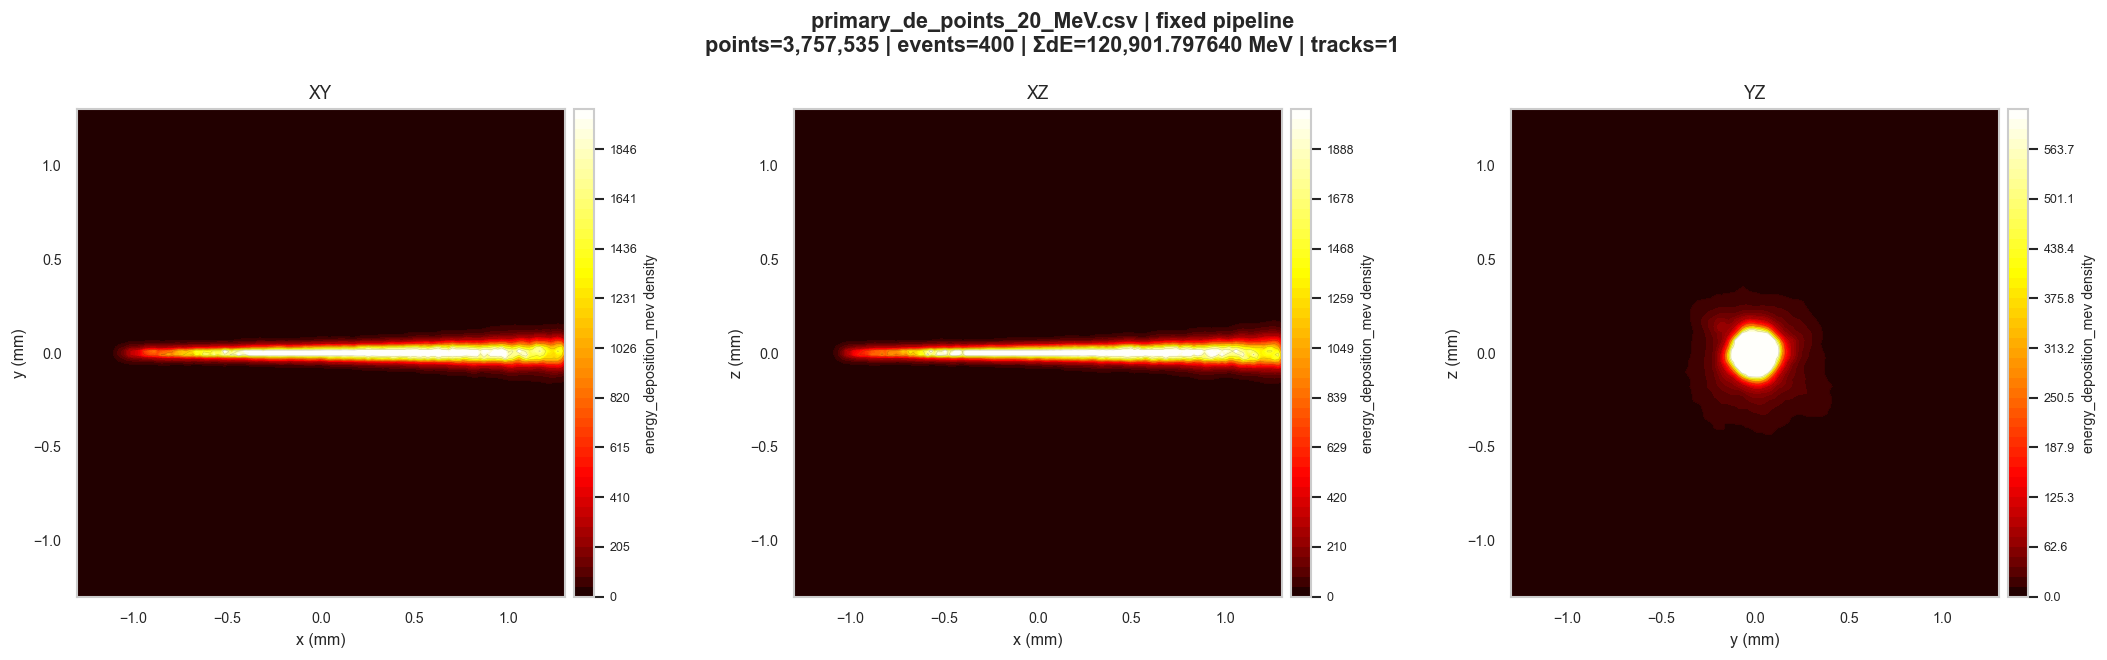

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


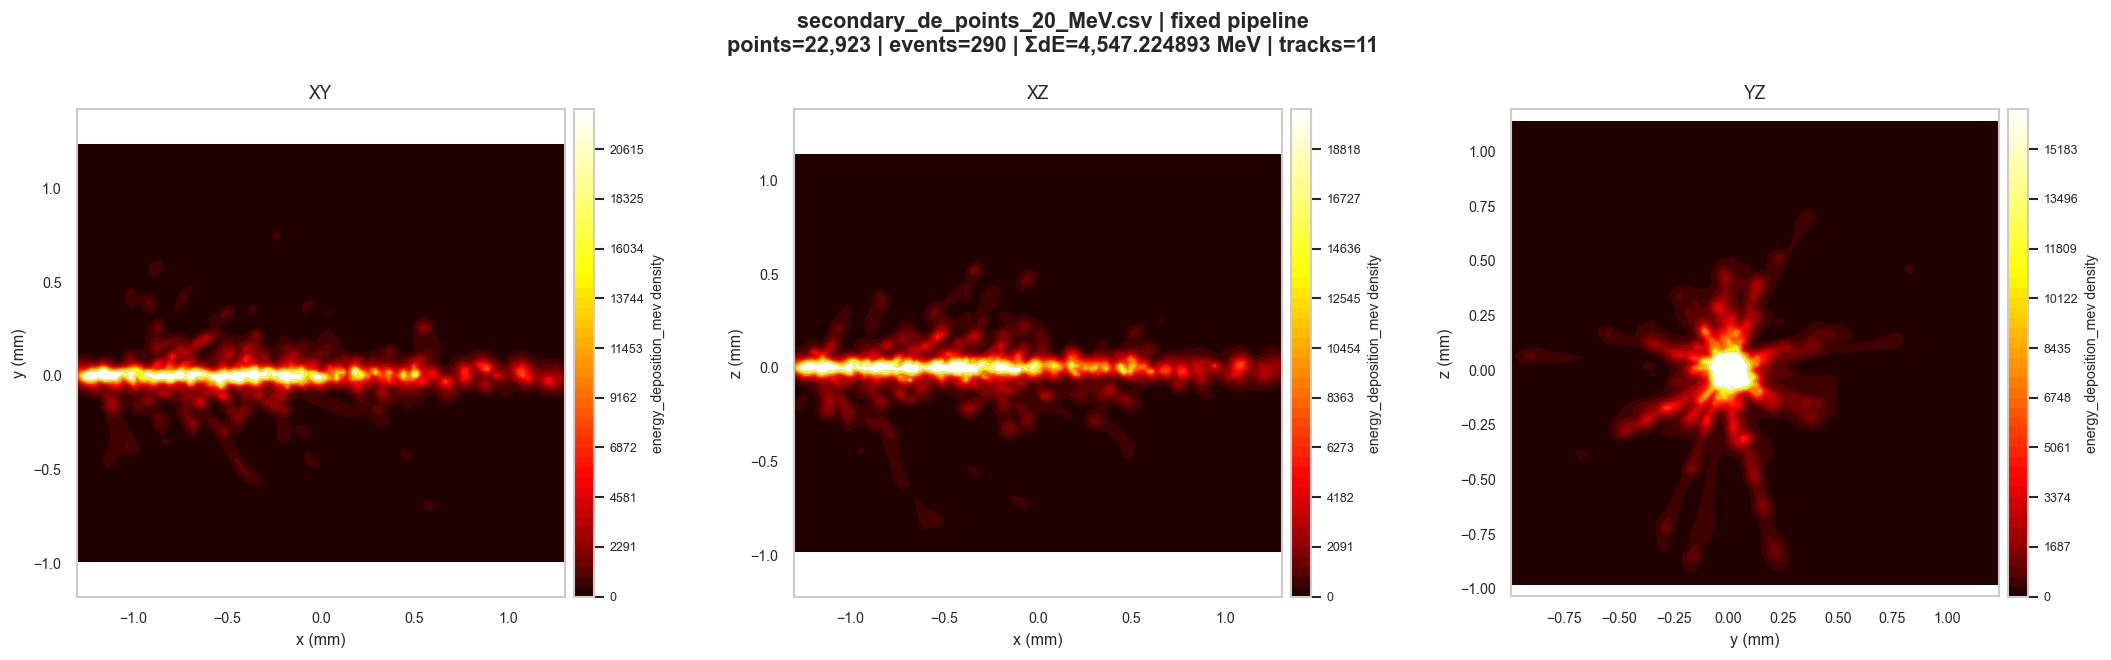

In [3]:
# Загрузка
df_primary_13_MeV = pd.read_csv("Effective traks/primary_de_points_20_MeV.csv")
df_secondary_13_MeV = pd.read_csv("Effective traks/secondary_de_points_20_MeV.csv")

output_primary_13_MeV = plot_fixed_heatmap_triplet(df_primary_13_MeV, "Effective traks/primary_de_points_20_MeV.csv")
output_secondary_13_MeV = plot_fixed_heatmap_triplet(df_secondary_13_MeV, "Effective traks/secondary_de_points_20_MeV.csv")

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


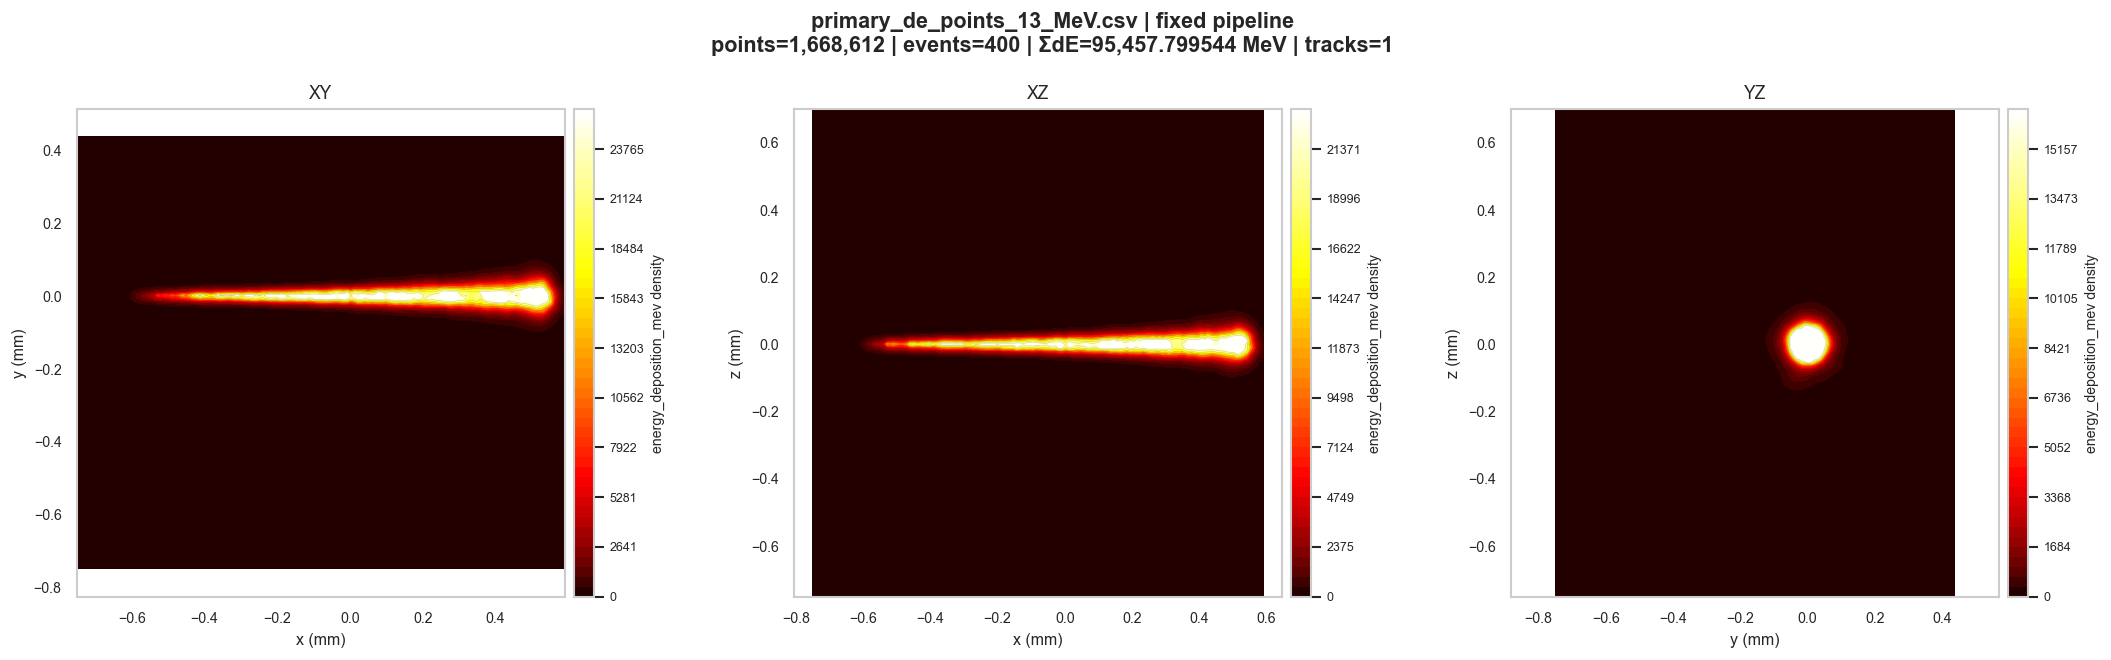

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


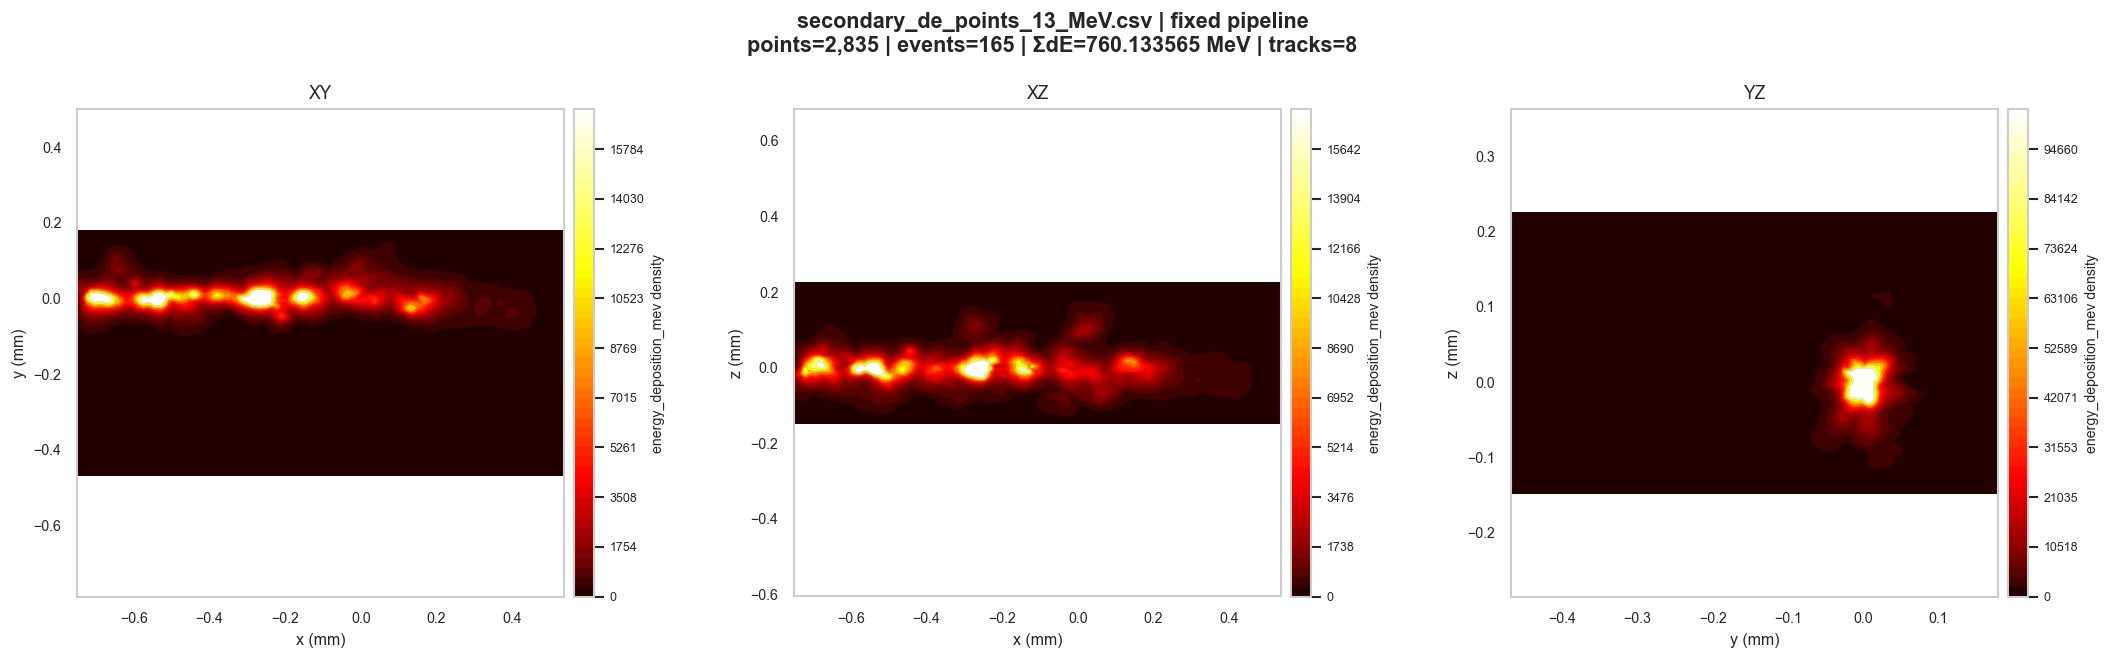

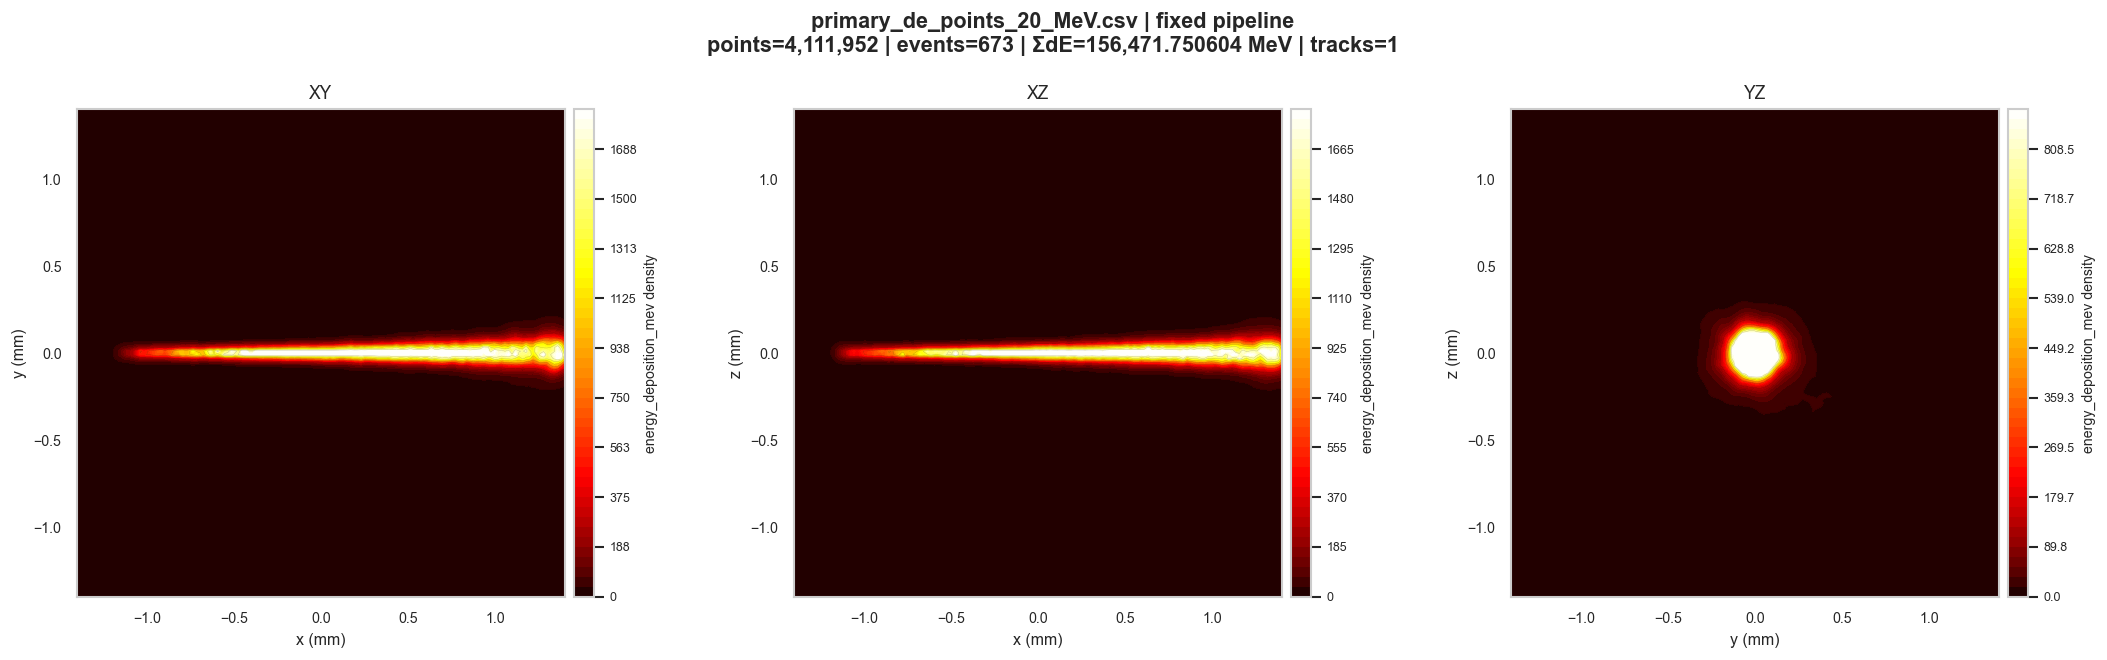

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


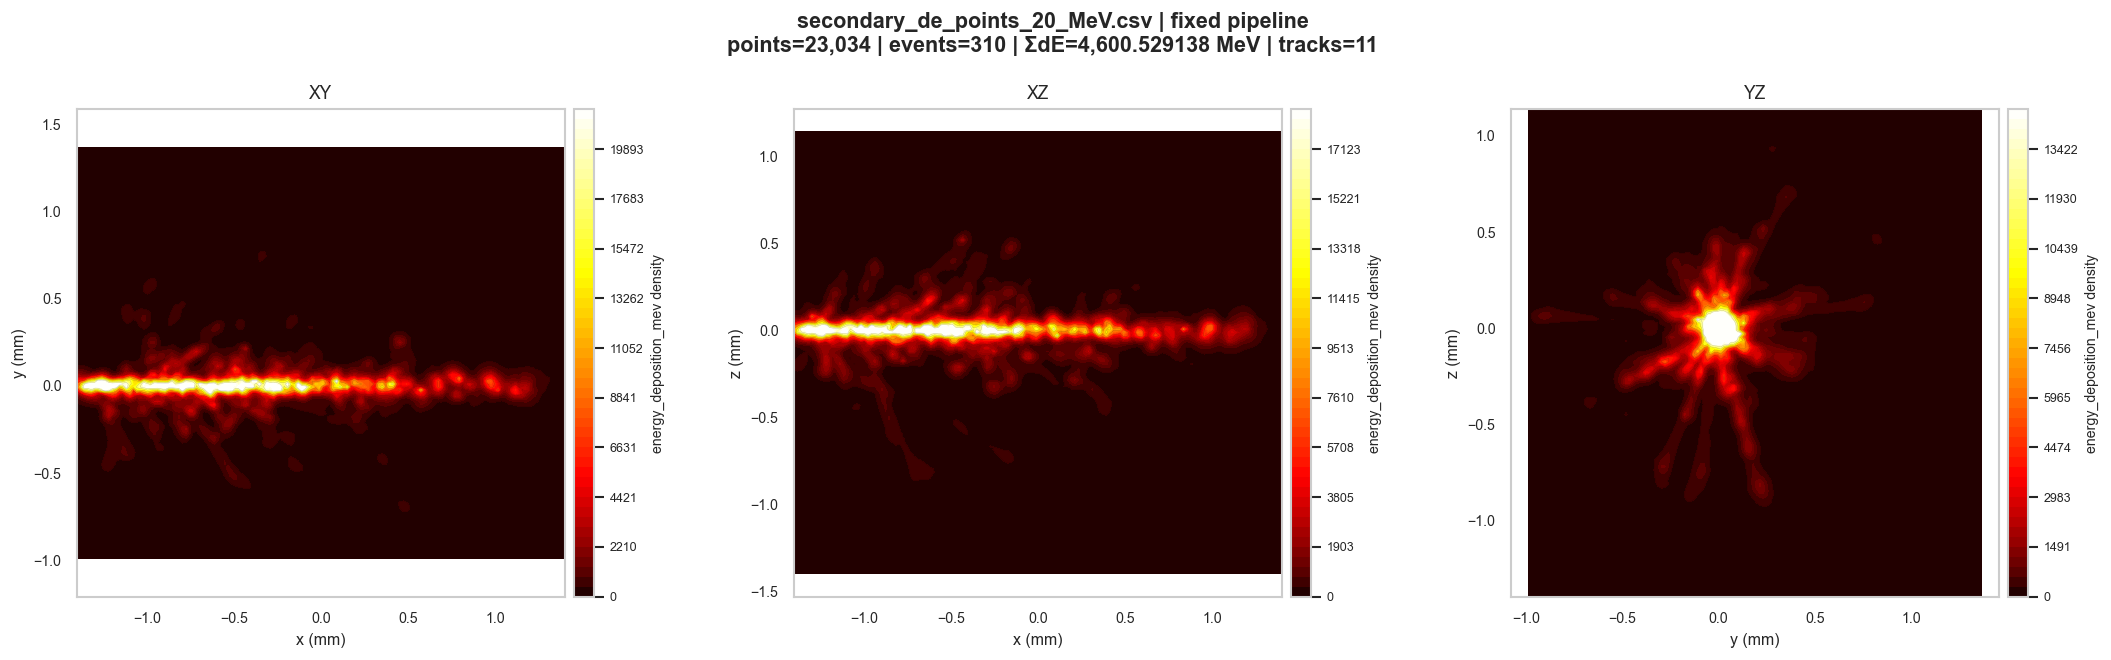

In [ ]:
# Загрузка
df_primary_13_MeV = pd.read_csv("Effective traks/primary_de_points_20_MeV.csv")
df_secondary_13_MeV = pd.read_csv("Effective traks/secondary_de_points_20_MeV.csv")

output_primary_13_MeV = plot_fixed_heatmap_triplet(df_primary_13_MeV, "primary_de_points_13_MeV.csv")
output_secondary_13_MeV = plot_fixed_heatmap_triplet(df_secondary_13_MeV, "secondary_de_points_13_MeV.csv")

df_primary_20_MeV = pd.read_csv("primary_de_points_20_MeV.csv")
df_secondary_20_MeV = pd.read_csv("secondary_de_points_20_MeV.csv")

output_primary_20_MeV = plot_fixed_heatmap_triplet(df_primary_20_MeV, "primary_de_points_20_MeV.csv")
output_secondary_20_MeV = plot_fixed_heatmap_triplet(df_secondary_20_MeV, "secondary_de_points_20_MeV.csv")

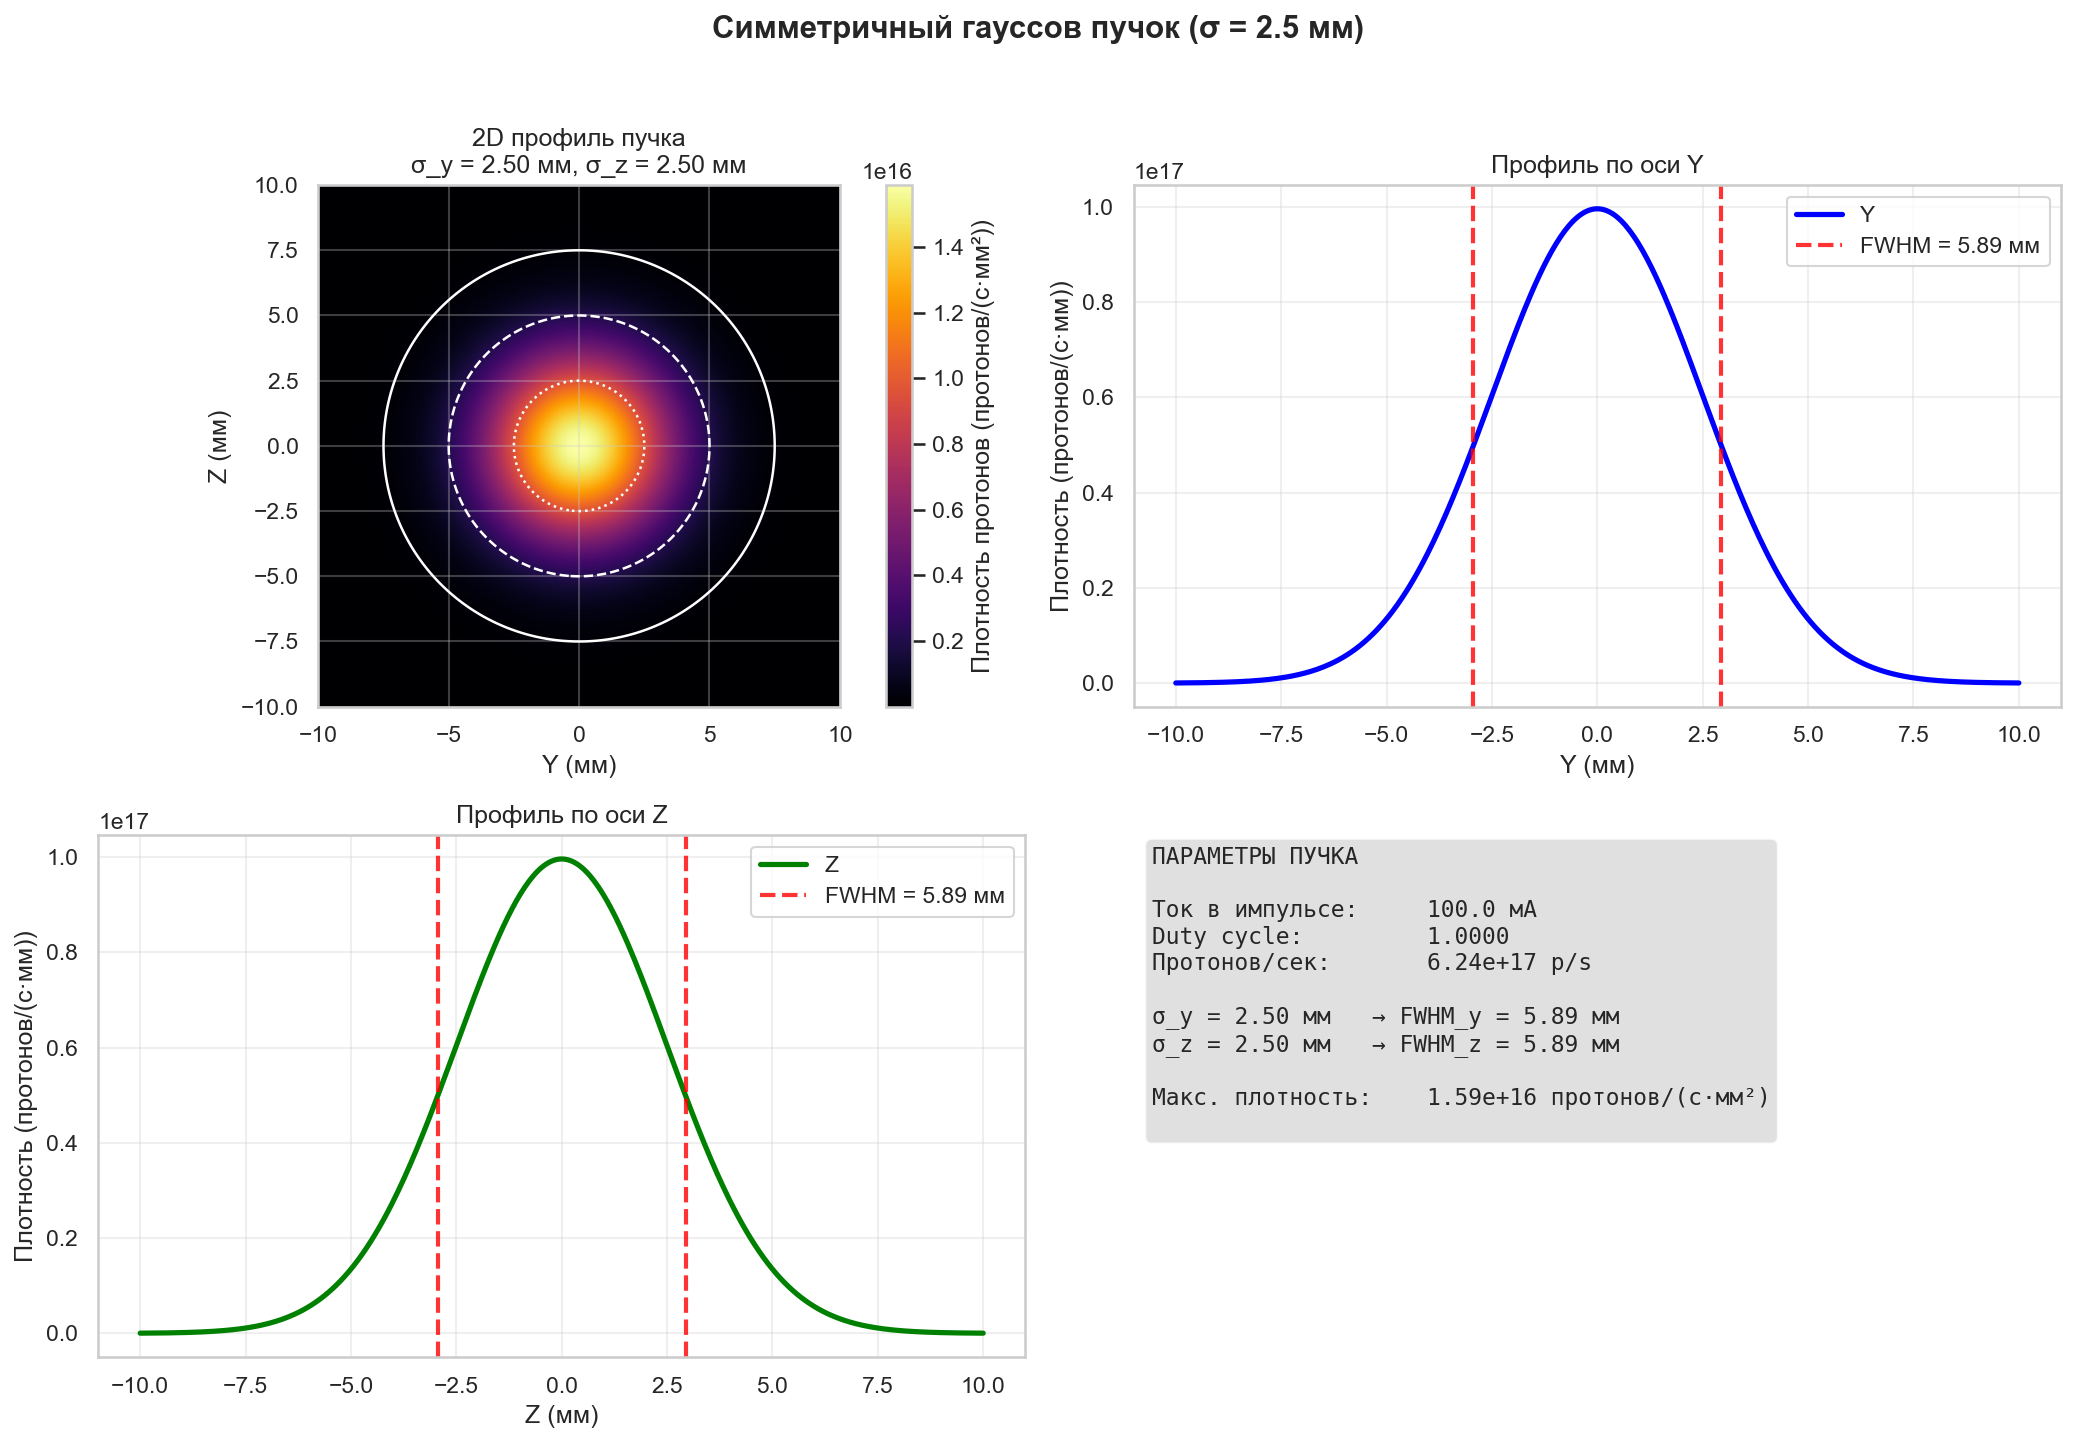

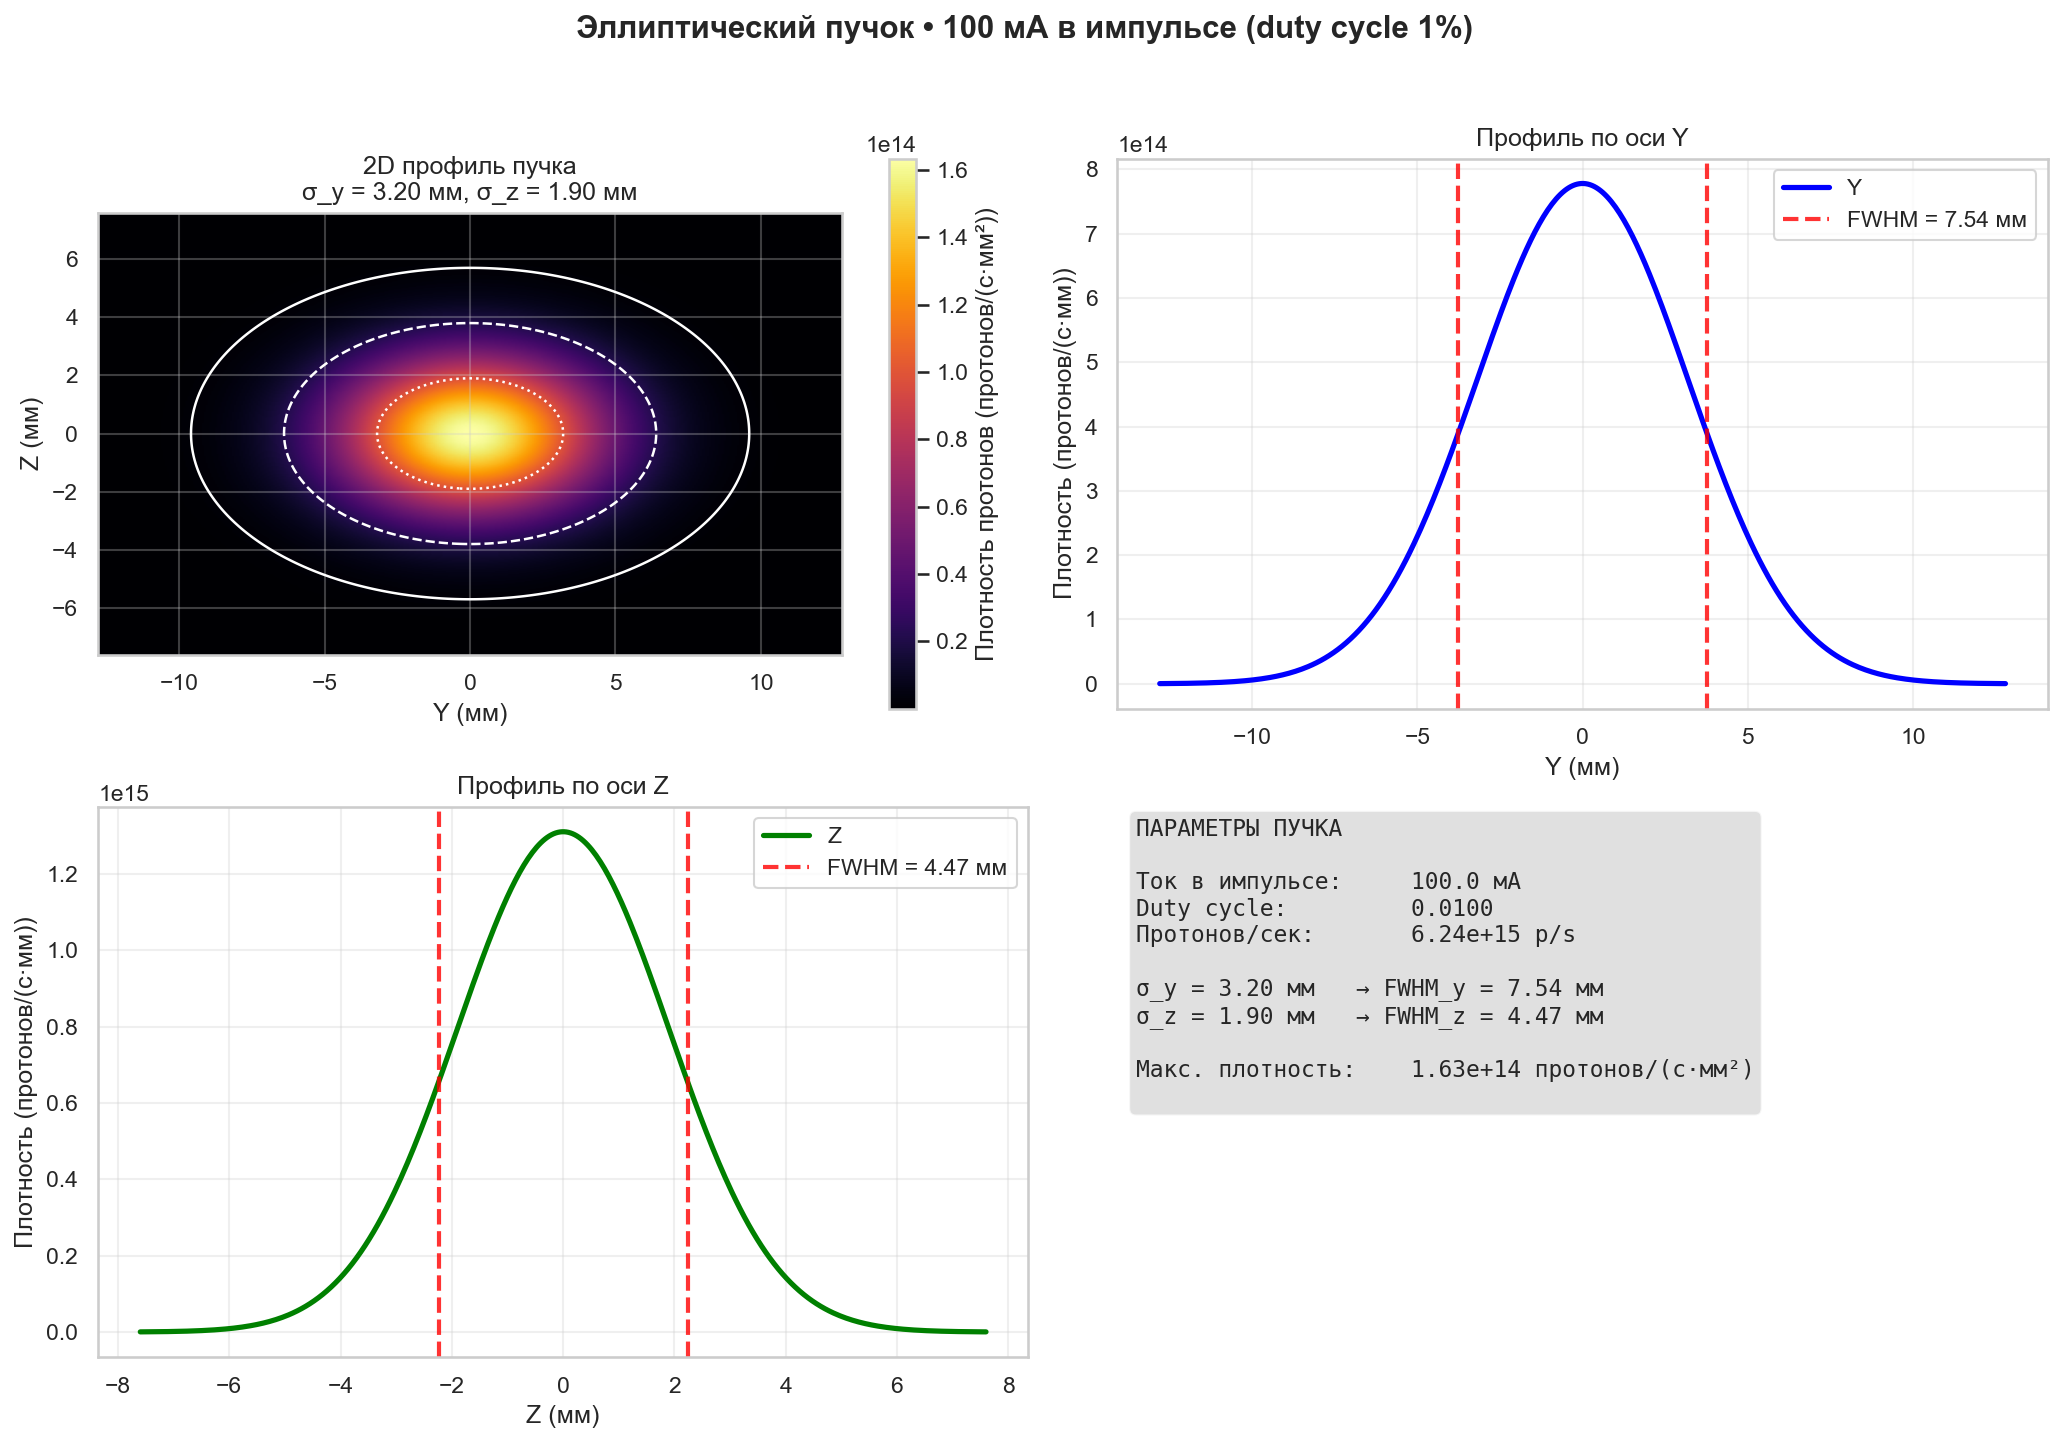

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_beam_profile(sigma_y_mm=2.5, sigma_z_mm=2.5, 
                      peak_current_mA=100.0, 
                      duty_cycle=1.0, 
                      title="Профиль пучка протонов"):
    
    # Создаём сетку
    range_y = 4 * sigma_y_mm
    range_z = 4 * sigma_z_mm
    y = np.linspace(-range_y, range_y, 400)
    z = np.linspace(-range_z, range_z, 400)
    Y, Z = np.meshgrid(y, z)
    
    # 2D Гауссов профиль (нормированный на 1)
    beam_2d = np.exp(- (Y**2)/(2*sigma_y_mm**2) - (Z**2)/(2*sigma_z_mm**2))
    beam_2d /= (2 * np.pi * sigma_y_mm * sigma_z_mm)
    
    # Реальная плотность протонов в секунду на мм²
    protons_per_sec = peak_current_mA * 1e-3 / 1.60217662e-19 * duty_cycle
    current_density = beam_2d * protons_per_sec
    
    # FWHM
    fwhm_y = 2.35482 * sigma_y_mm   # более точный коэффициент
    fwhm_z = 2.35482 * sigma_z_mm
    
    fig = plt.figure(figsize=(14, 10))
    
    # 1. 2D карта плотности
    ax1 = fig.add_subplot(2, 2, 1)
    im = ax1.imshow(current_density, 
                    extent=[y.min(), y.max(), z.min(), z.max()],
                    origin='lower', cmap='inferno', aspect='equal')
    
    cbar = plt.colorbar(im, ax=ax1, label='Плотность протонов (протонов/(с·мм²))')
    cbar.formatter.set_powerlimits((0, 0))
    
    # Контуры — с защитой от ошибки
    max_val = np.max(current_density)
    if max_val > 0:
        # Делаем уровни строго возрастающими
        contour_levels = [max_val * np.exp(-0.5 * r**2) for r in [1, 2, 3]]
        # Убираем возможные дубликаты и сортируем
        contour_levels = sorted(set([round(l, 10) for l in contour_levels if l > 0]))
        
        if len(contour_levels) >= 2:
            ax1.contour(Y, Z, current_density, levels=contour_levels, 
                        colors='white', linestyles=['-', '--', ':'], linewidths=1.2)
        elif len(contour_levels) == 1:
            ax1.contour(Y, Z, current_density, levels=contour_levels, 
                        colors='white', linewidths=1.2)
    
    ax1.set_xlabel('Y (мм)')
    ax1.set_ylabel('Z (мм)')
    ax1.set_title(f'2D профиль пучка\nσ_y = {sigma_y_mm:.2f} мм, σ_z = {sigma_z_mm:.2f} мм')
    ax1.grid(True, alpha=0.3)
    
    # 2. 1D профиль по Y
    ax2 = fig.add_subplot(2, 2, 2)
    profile_y = np.exp(-y**2 / (2*sigma_y_mm**2)) / (np.sqrt(2*np.pi)*sigma_y_mm)
    ax2.plot(y, profile_y * protons_per_sec, 'b-', linewidth=2.5, label='Y')
    ax2.axvline(-fwhm_y/2, color='red', linestyle='--', alpha=0.8)
    ax2.axvline( fwhm_y/2, color='red', linestyle='--', alpha=0.8, 
                label=f'FWHM = {fwhm_y:.2f} мм')
    ax2.set_xlabel('Y (мм)')
    ax2.set_ylabel('Плотность (протонов/(с·мм))')
    ax2.set_title('Профиль по оси Y')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # 3. 1D профиль по Z
    ax3 = fig.add_subplot(2, 2, 3)
    profile_z = np.exp(-z**2 / (2*sigma_z_mm**2)) / (np.sqrt(2*np.pi)*sigma_z_mm)
    ax3.plot(z, profile_z * protons_per_sec, 'g-', linewidth=2.5, label='Z')
    ax3.axvline(-fwhm_z/2, color='red', linestyle='--', alpha=0.8)
    ax3.axvline( fwhm_z/2, color='red', linestyle='--', alpha=0.8, 
                label=f'FWHM = {fwhm_z:.2f} мм')
    ax3.set_xlabel('Z (мм)')
    ax3.set_ylabel('Плотность (протонов/(с·мм))')
    ax3.set_title('Профиль по оси Z')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # 4. Информация
    ax4 = fig.add_subplot(2, 2, 4)
    ax4.axis('off')
    info_text = f"""ПАРАМЕТРЫ ПУЧКА

Ток в импульсе:     {peak_current_mA:.1f} мА
Duty cycle:         {duty_cycle:.4f}
Протонов/сек:       {protons_per_sec:.2e} p/s

σ_y = {sigma_y_mm:.2f} мм   → FWHM_y = {fwhm_y:.2f} мм
σ_z = {sigma_z_mm:.2f} мм   → FWHM_z = {fwhm_z:.2f} мм

Макс. плотность:    {np.max(current_density):.2e} протонов/(с·мм²)
"""
    ax4.text(0.02, 0.98, info_text, fontsize=11, va='top', family='monospace', 
             bbox=dict(boxstyle="round", facecolor="lightgray", alpha=0.7))

    fig.suptitle(title, fontsize=15, fontweight='bold', y=0.96)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


# ====================== Запуск ======================

plot_beam_profile(sigma_y_mm=2.5, sigma_z_mm=2.5, 
                  peak_current_mA=100, duty_cycle=1.0,
                  title="Симметричный гауссов пучок (σ = 2.5 мм)")

plot_beam_profile(sigma_y_mm=3.2, sigma_z_mm=1.9, 
                  peak_current_mA=100, duty_cycle=0.01,
                  title="Эллиптический пучок • 100 мА в импульсе (duty cycle 1%)")